# Flight time modelling: Trans-Tasman

In [36]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import dask
import pandas as pd
from jetstream_interpolate_convcnp.paths.locations import AUCKLAND, SYDNEY, CHRISTCHURCH, WELLINGTON, PERTH, SINGAPORE, MELBOURNE

In [37]:
DATA_BASE = "/mnt/hdd/jetstream/data/development"

CEDA = "/ceda/july_2019/"
ERA5 = "/era5/july2019/reanalysis_2019_07"
ECMWF = "/ecmwf/july_2019/"

ecmwf_path = os.path.join(DATA_BASE, ECMWF)
era5_path = os.path.join(DATA_BASE, ERA5)
ceda_path = os.path.join(DATA_BASE, CEDA)

g = 9.80665

In [38]:
era5_ds = xr.open_mfdataset(f"{DATA_BASE}{era5_path}/pressure/2019/07/*.nc", combine="by_coords")
ecmwf_ds = xr.open_dataset(f"{DATA_BASE}{ecmwf_path}/ecmwf_forecast.nc")

In [41]:
# crop to a box from melbourne to auckland
lon_min = 143
lon_max = 176
lat_min = -50
lat_max = -30

ecmwf_ds = ecmwf_ds.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
era5_ds = era5_ds.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_max, lat_min))

In [42]:
# Create a new pressure_level dimension for ECMWF
pressure_levels = [200, 250, 300, 500, 700]
ecmwf_ds = ecmwf_ds.assign_coords(pressure_level=pressure_levels)

# Stack UGRD_XXXmb & VGRD_XXXmb & HGT_XXXmb into a single variable with a pressure_level dimension
ecmwf_u = ecmwf_ds[[f'UGRD_{p}mb' for p in pressure_levels]].to_array(dim='pressure_level').assign_coords(pressure_level=pressure_levels).transpose('time', 'pressure_level', 'latitude', 'longitude')
ecmwf_v = ecmwf_ds[[f'VGRD_{p}mb' for p in pressure_levels]].to_array(dim='pressure_level').assign_coords(pressure_level=pressure_levels).transpose('time', 'pressure_level', 'latitude', 'longitude')
ecmwf_z = ecmwf_ds[[f'HGT_{p}mb' for p in pressure_levels]].to_array(dim='pressure_level').assign_coords(pressure_level=pressure_levels).transpose('time', 'pressure_level', 'latitude', 'longitude')

# Create a new dataset with the stacked variables
ecmwf_stacked = xr.Dataset({
    'u': ecmwf_u,
    'v': ecmwf_v,
    'z': ecmwf_z
}, coords={
    'time': ecmwf_ds.time,
    'pressure_level': pressure_levels,
    'latitude': ecmwf_ds.latitude,
    'longitude': ecmwf_ds.longitude
})

# rename 'time' to 'valid_time' to match ERA5
ecmwf_stacked = ecmwf_stacked.rename({'time': 'valid_time'})

# regrid ECMWF to ERA5 grid
ecmwf_ds = ecmwf_stacked.interp(latitude=era5_ds.latitude, longitude=era5_ds.longitude, method='linear')

# Test Flight Path Optimization

In [44]:
from jetstream_interpolate_convcnp.paths.losses import LossWeights
from jetstream_interpolate_convcnp.paths.aircraft import PROFILES
from jetstream_interpolate_convcnp.paths.windfield import WindField
from jetstream_interpolate_convcnp.paths.trajectory import Trajectory
from jetstream_interpolate_convcnp.paths.optimizer import TrajectoryOptimizer
from jetstream_interpolate_convcnp.paths.plotting import plot_trajectory

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

In [45]:
flights = [
    {"to": MELBOURNE, "from": AUCKLAND, "time": '2019-07-01T18:00:00.000000000', "profile": PROFILES["widebody_jet"]},
    {"to": MELBOURNE, "from": AUCKLAND, "time": '2019-07-02T06:00:00.000000000', "profile": PROFILES["narrowbody_jet"]},
    {"to": AUCKLAND, "from": MELBOURNE, "time": '2019-07-03T18:00:00.000000000', "profile": PROFILES["narrowbody_jet"]},
    {"to": AUCKLAND, "from": MELBOURNE, "time": '2019-07-04T06:00:00.000000000', "profile": PROFILES["widebody_jet"]},
    {"to": MELBOURNE, "from": AUCKLAND, "time": '2019-07-05T18:00:00.000000000', "profile": PROFILES["widebody_jet"]},
    {"to": MELBOURNE, "from": AUCKLAND, "time": '2019-07-06T06:00:00.000000000', "profile": PROFILES["narrowbody_jet"]},
    {"to": AUCKLAND, "from": MELBOURNE, "time": '2019-07-07T18:00:00.000000000', "profile": PROFILES["narrowbody_jet"]},
    {"to": AUCKLAND, "from": MELBOURNE, "time": '2019-07-08T06:00:00.000000000', "profile": PROFILES["widebody_jet"]},
    {"to": MELBOURNE, "from": AUCKLAND, "time": '2019-07-09T18:00:00.000000000', "profile": PROFILES["widebody_jet"]},
    {"to": MELBOURNE, "from": AUCKLAND, "time": '2019-07-10T06:00:00.000000000', "profile": PROFILES["narrowbody_jet"]},
    {"to": AUCKLAND, "from": MELBOURNE, "time": '2019-07-11T18:00:00.000000000', "profile": PROFILES["narrowbody_jet"]},
    {"to": AUCKLAND, "from": MELBOURNE, "time": '2019-07-12T06:00:00.000000000', "profile": PROFILES["widebody_jet"]},
    {"to": MELBOURNE, "from": AUCKLAND, "time": '2019-07-13T18:00:00.000000000', "profile": PROFILES["widebody_jet"]},
    {"to": MELBOURNE, "from": AUCKLAND, "time": '2019-07-14T06:00:00.000000000', "profile": PROFILES["narrowbody_jet"]},
    {"to": AUCKLAND, "from": MELBOURNE, "time": '2019-07-15T18:00:00.000000000', "profile": PROFILES["narrowbody_jet"]},
    {"to": AUCKLAND, "from": MELBOURNE, "time": '2019-07-16T06:00:00.000000000', "profile": PROFILES["widebody_jet"]},
    {"to": MELBOURNE, "from": AUCKLAND, "time": '2019-07-17T18:00:00.000000000', "profile": PROFILES["widebody_jet"]},
    {"to": MELBOURNE, "from": AUCKLAND, "time": '2019-07-18T06:00:00.000000000', "profile": PROFILES["narrowbody_jet"]},
    {"to": AUCKLAND, "from": MELBOURNE, "time": '2019-07-19T18:00:00.000000000', "profile": PROFILES["narrowbody_jet"]},
    {"to": AUCKLAND, "from": MELBOURNE, "time": '2019-07-20T06:00:00.000000000', "profile": PROFILES["widebody_jet"]},
    {"to": MELBOURNE, "from": AUCKLAND, "time": '2019-07-21T18:00:00.000000000', "profile": PROFILES["widebody_jet"]},
    {"to": MELBOURNE, "from": AUCKLAND, "time": '2019-07-22T06:00:00.000000000', "profile": PROFILES["narrowbody_jet"]},
    {"to": AUCKLAND, "from": MELBOURNE, "time": '2019-07-23T18:00:00.000000000', "profile": PROFILES["narrowbody_jet"]},
    {"to": AUCKLAND, "from": MELBOURNE, "time": '2019-07-24T06:00:00.000000000', "profile": PROFILES["widebody_jet"]},
    {"to": MELBOURNE, "from": AUCKLAND, "time": '2019-07-25T18:00:00.000000000', "profile": PROFILES["widebody_jet"]},
    {"to": MELBOURNE, "from": AUCKLAND, "time": '2019-07-26T06:00:00.000000000', "profile": PROFILES["narrowbody_jet"]},
    {"to": AUCKLAND, "from": MELBOURNE, "time": '2019-07-27T18:00:00.000000000', "profile": PROFILES["narrowbody_jet"]},
    {"to": AUCKLAND, "from": MELBOURNE, "time": '2019-07-28T06:00:00.000000000', "profile": PROFILES["widebody_jet"]}
]

Processed flight from (-36.8485, 174.7634, 0.0) to (-37.8136, 144.9631, 0.0) at 2019-07-01T18:00:00.000000000. Fuel savings: 6.32 kg
Fuel savings for the day (estimate, NZD) = 48.03 NZD
Processed flight from (-36.8485, 174.7634, 0.0) to (-37.8136, 144.9631, 0.0) at 2019-07-02T06:00:00.000000000. Fuel savings: 4.85 kg
Fuel savings for the day (estimate, NZD) = 36.83 NZD
Processed flight from (-37.8136, 144.9631, 0.0) to (-36.8485, 174.7634, 0.0) at 2019-07-03T18:00:00.000000000. Fuel savings: 5.30 kg
Fuel savings for the day (estimate, NZD) = 40.31 NZD
Processed flight from (-37.8136, 144.9631, 0.0) to (-36.8485, 174.7634, 0.0) at 2019-07-04T06:00:00.000000000. Fuel savings: 24.97 kg
Fuel savings for the day (estimate, NZD) = 189.78 NZD
Processed flight from (-36.8485, 174.7634, 0.0) to (-37.8136, 144.9631, 0.0) at 2019-07-05T18:00:00.000000000. Fuel savings: 5.15 kg
Fuel savings for the day (estimate, NZD) = 39.15 NZD
Processed flight from (-36.8485, 174.7634, 0.0) to (-37.8136, 144.96

/home/lennoxc/jetstream/jetstream-interpolate-convcnp/src/jetstream_interpolate_convcnp/paths/plotting.py:90: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(12, 8))


Processed flight from (-37.8136, 144.9631, 0.0) to (-36.8485, 174.7634, 0.0) at 2019-07-11T18:00:00.000000000. Fuel savings: 22.06 kg
Fuel savings for the day (estimate, NZD) = 167.69 NZD
Processed flight from (-37.8136, 144.9631, 0.0) to (-36.8485, 174.7634, 0.0) at 2019-07-12T06:00:00.000000000. Fuel savings: 16.03 kg
Fuel savings for the day (estimate, NZD) = 121.82 NZD
Processed flight from (-36.8485, 174.7634, 0.0) to (-37.8136, 144.9631, 0.0) at 2019-07-13T18:00:00.000000000. Fuel savings: 20.86 kg
Fuel savings for the day (estimate, NZD) = 158.56 NZD
Processed flight from (-36.8485, 174.7634, 0.0) to (-37.8136, 144.9631, 0.0) at 2019-07-14T06:00:00.000000000. Fuel savings: 51.19 kg
Fuel savings for the day (estimate, NZD) = 389.03 NZD
Processed flight from (-37.8136, 144.9631, 0.0) to (-36.8485, 174.7634, 0.0) at 2019-07-15T18:00:00.000000000. Fuel savings: 23.42 kg
Fuel savings for the day (estimate, NZD) = 178.03 NZD
Processed flight from (-37.8136, 144.9631, 0.0) to (-36.8485

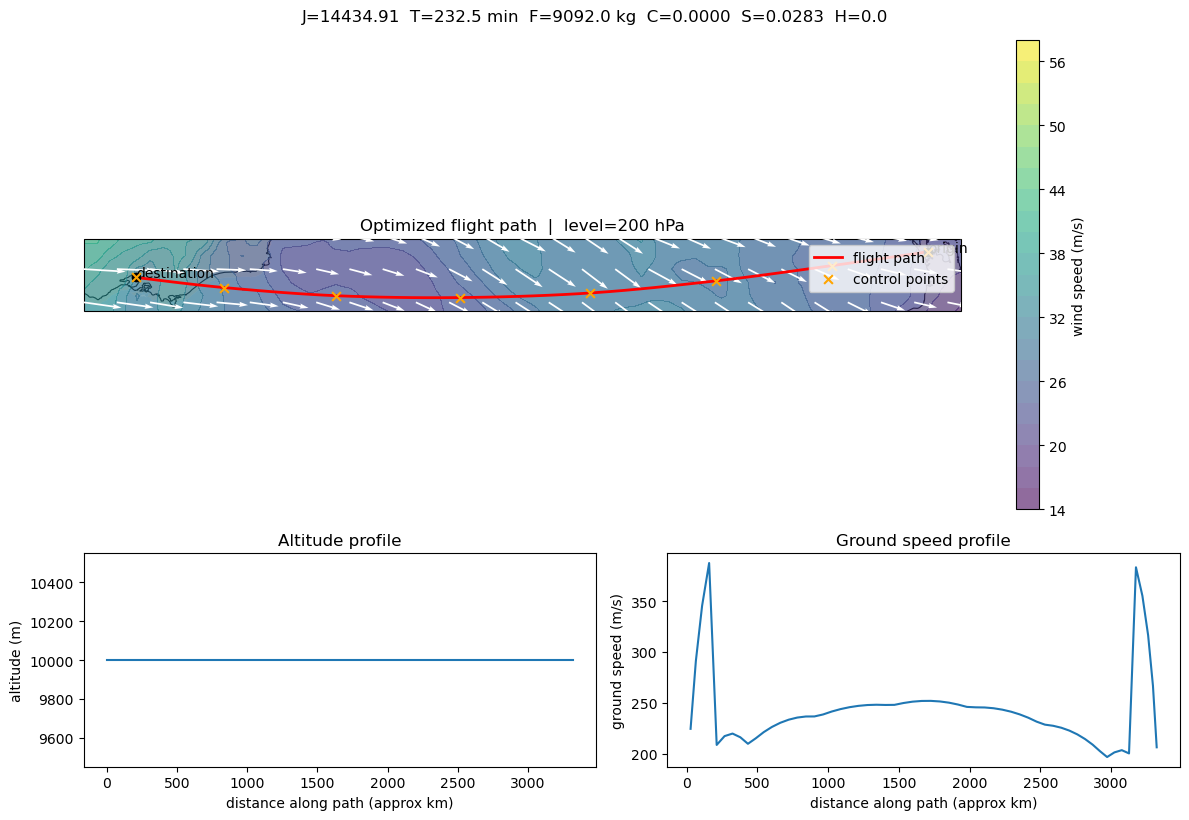

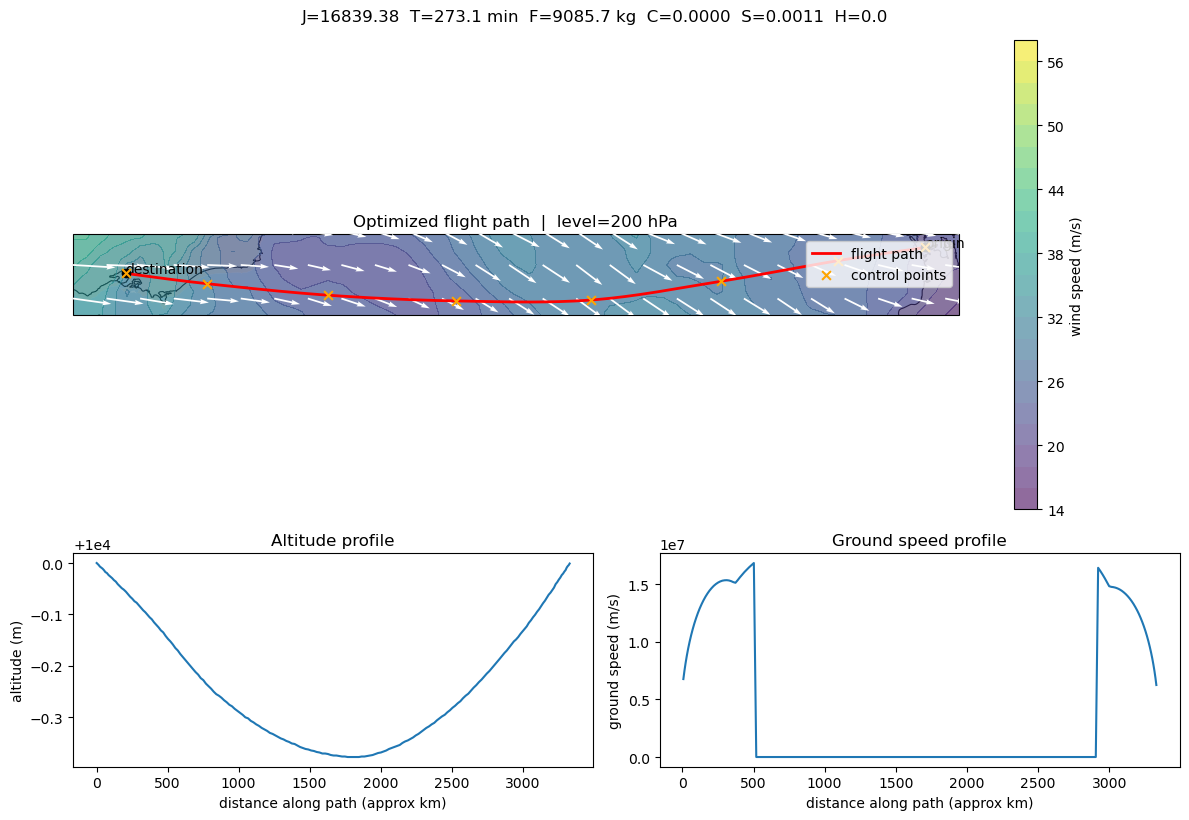

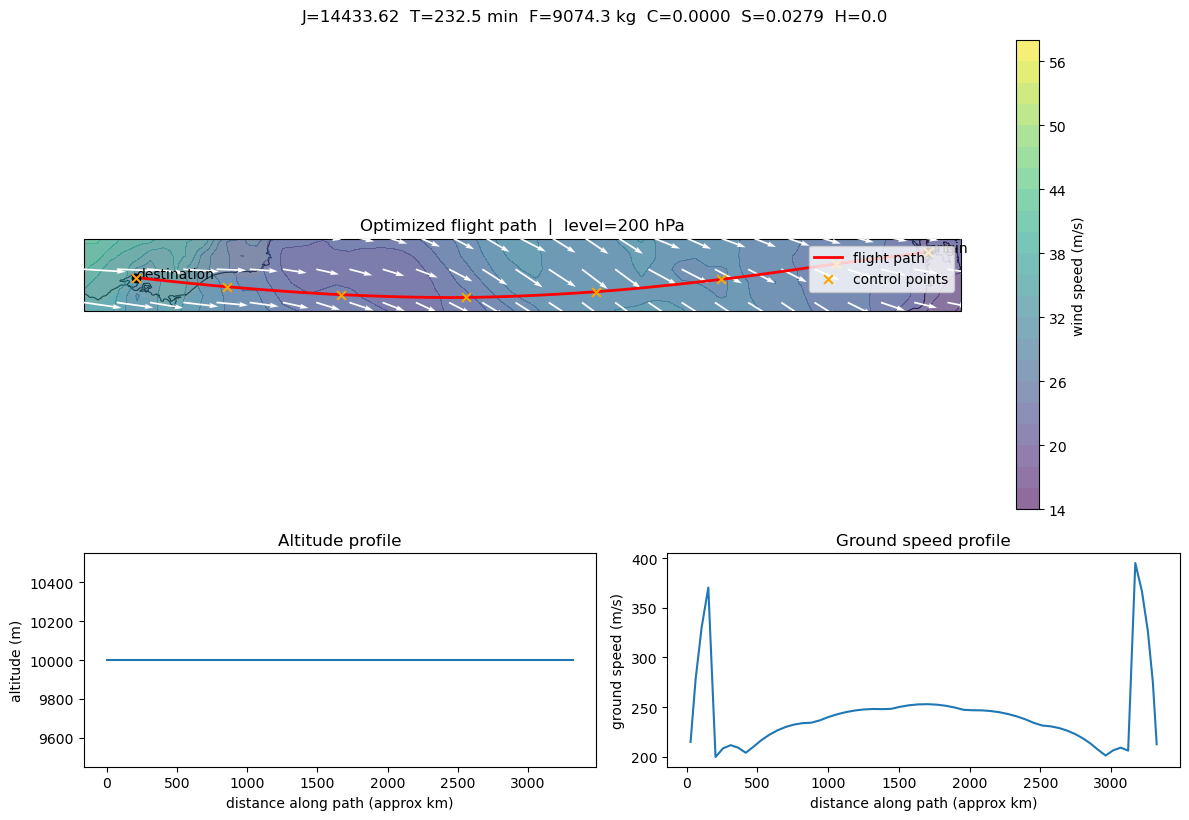

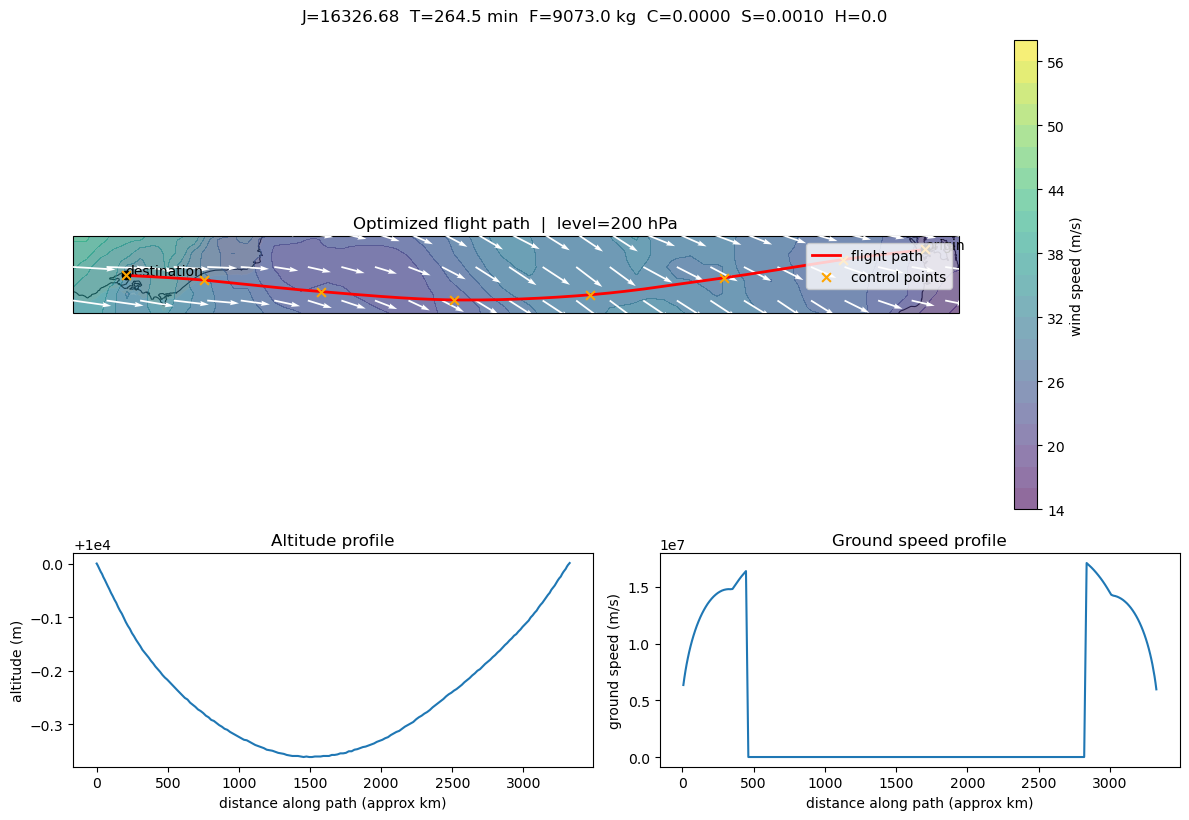

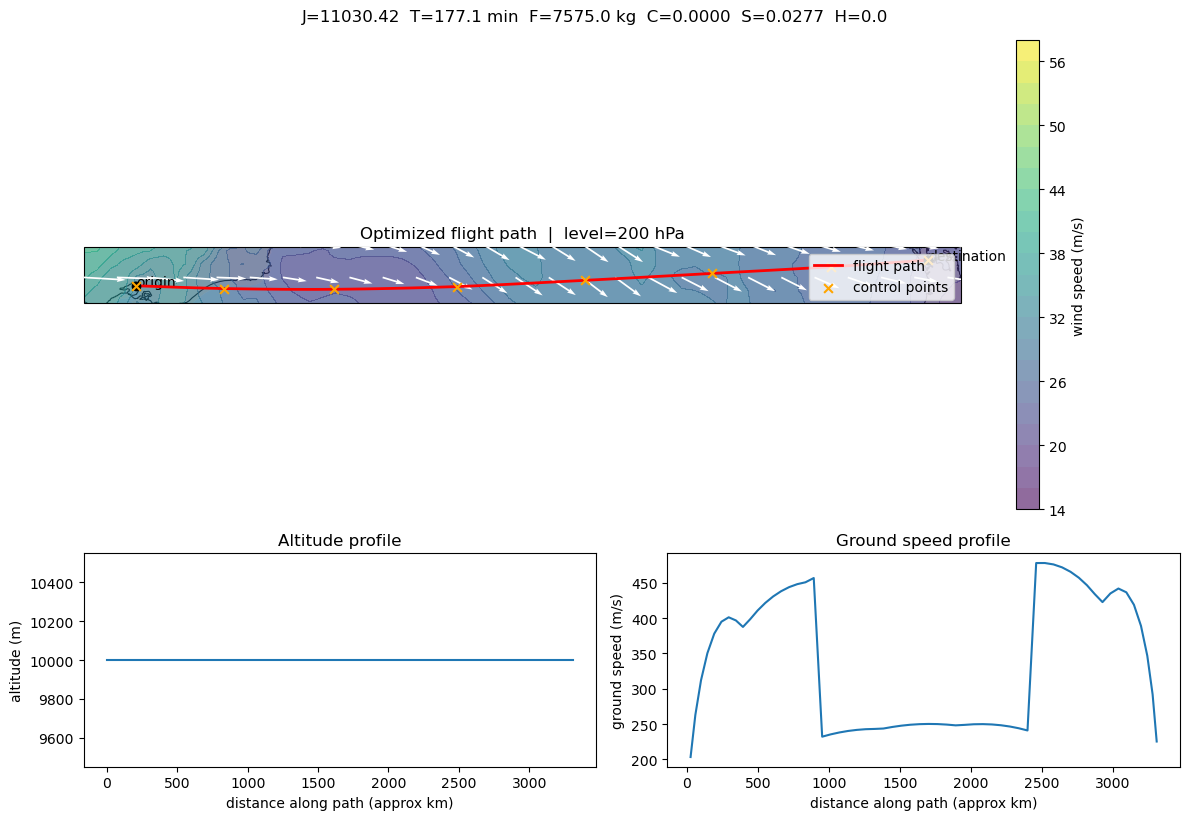

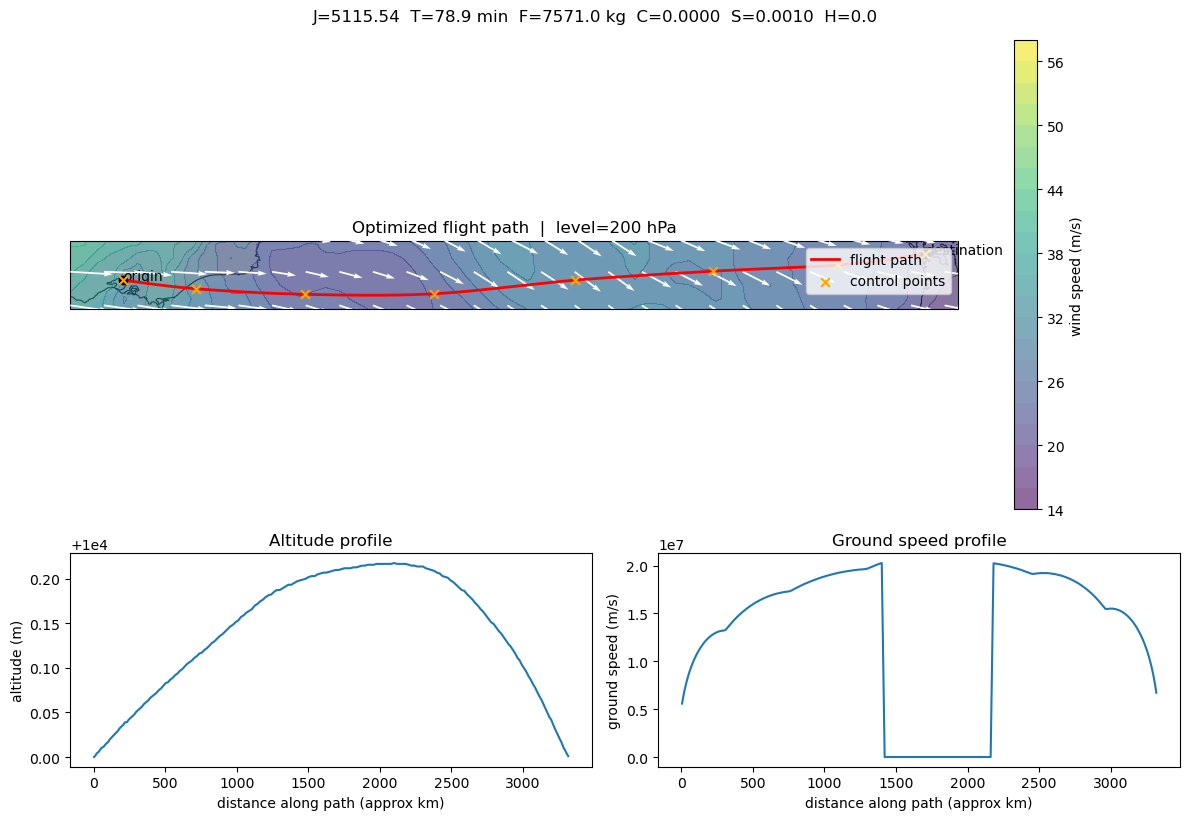

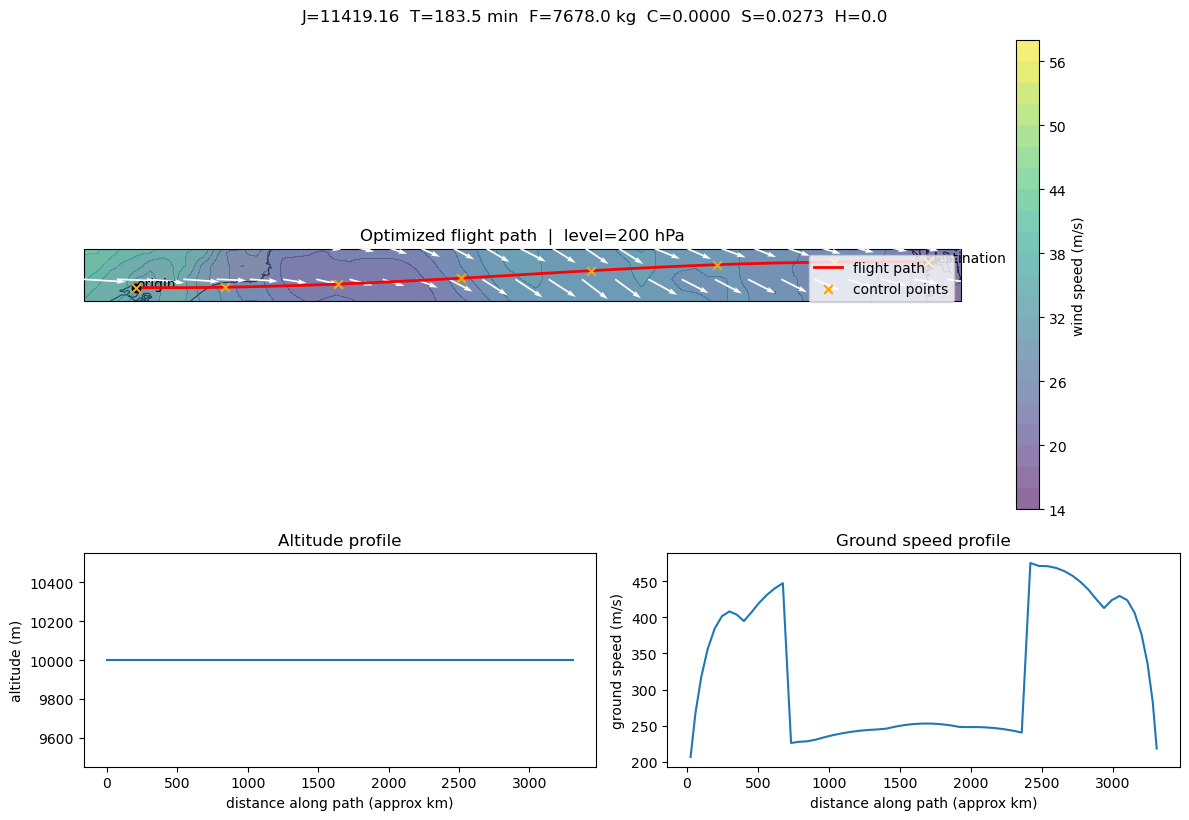

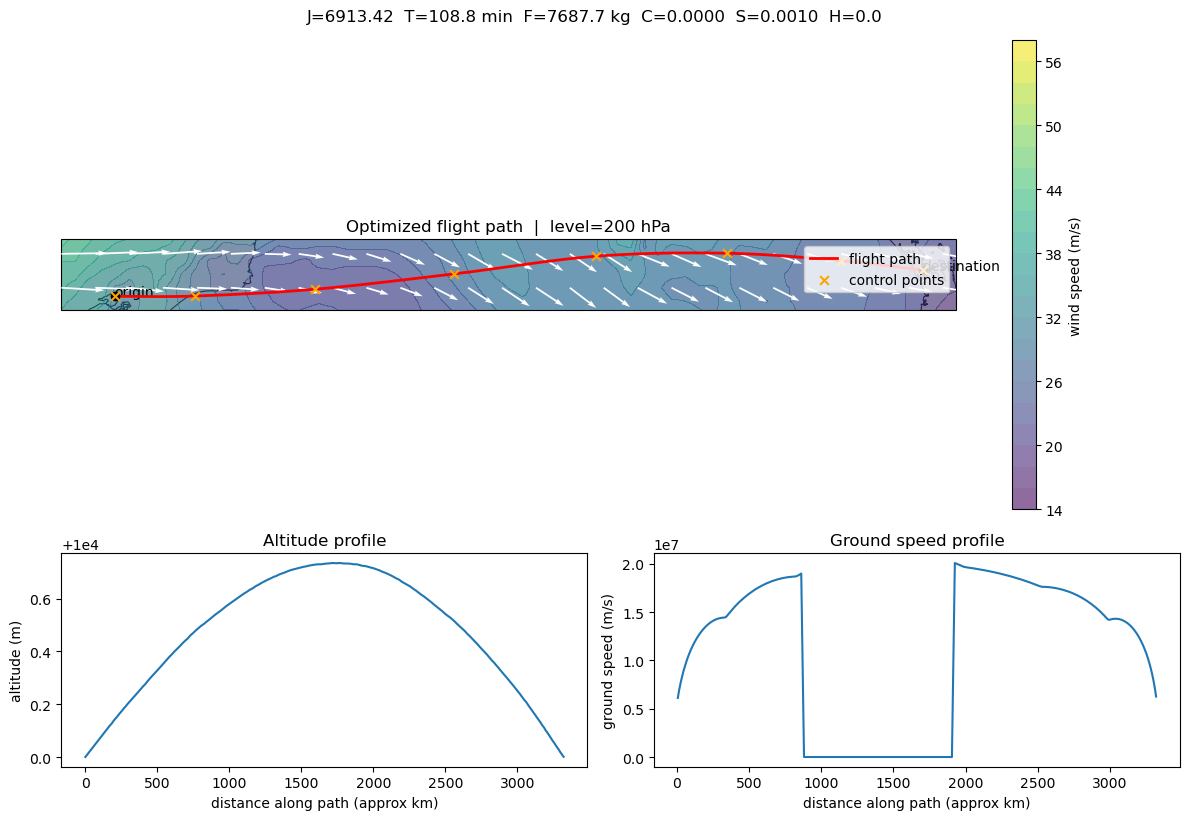

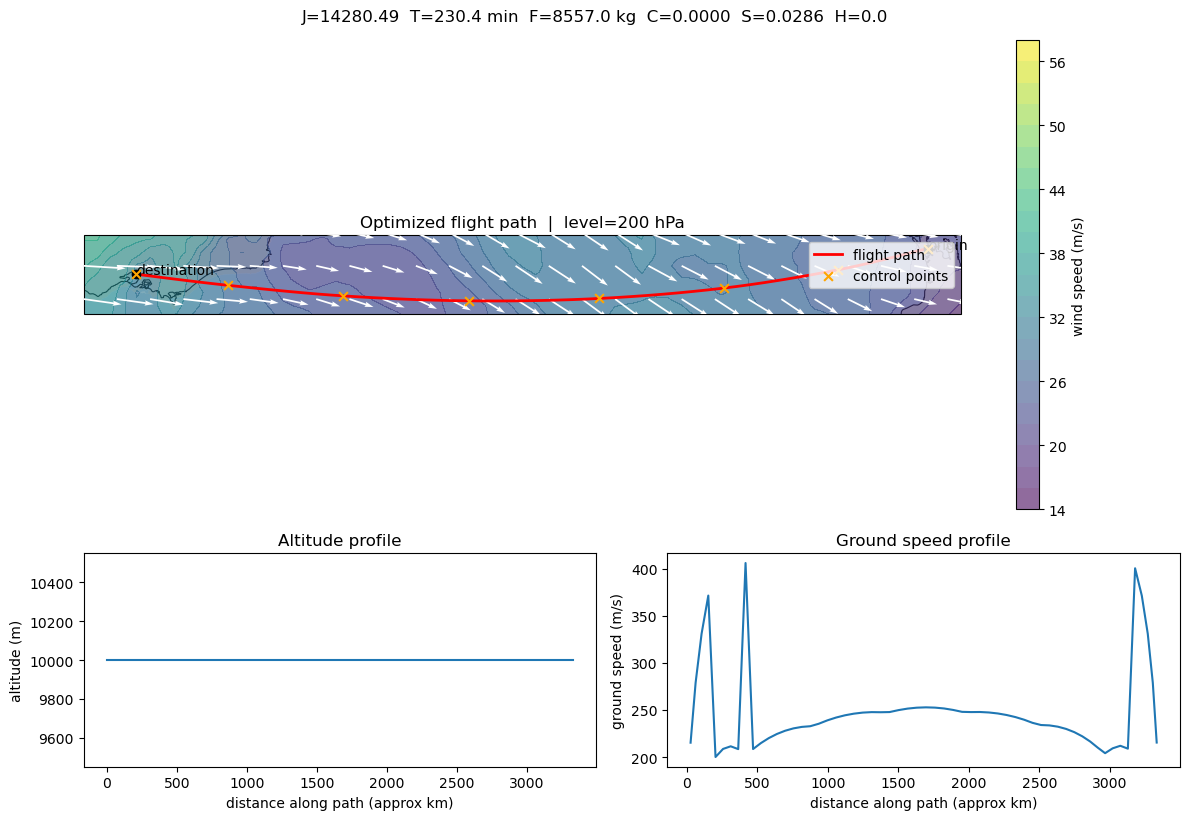

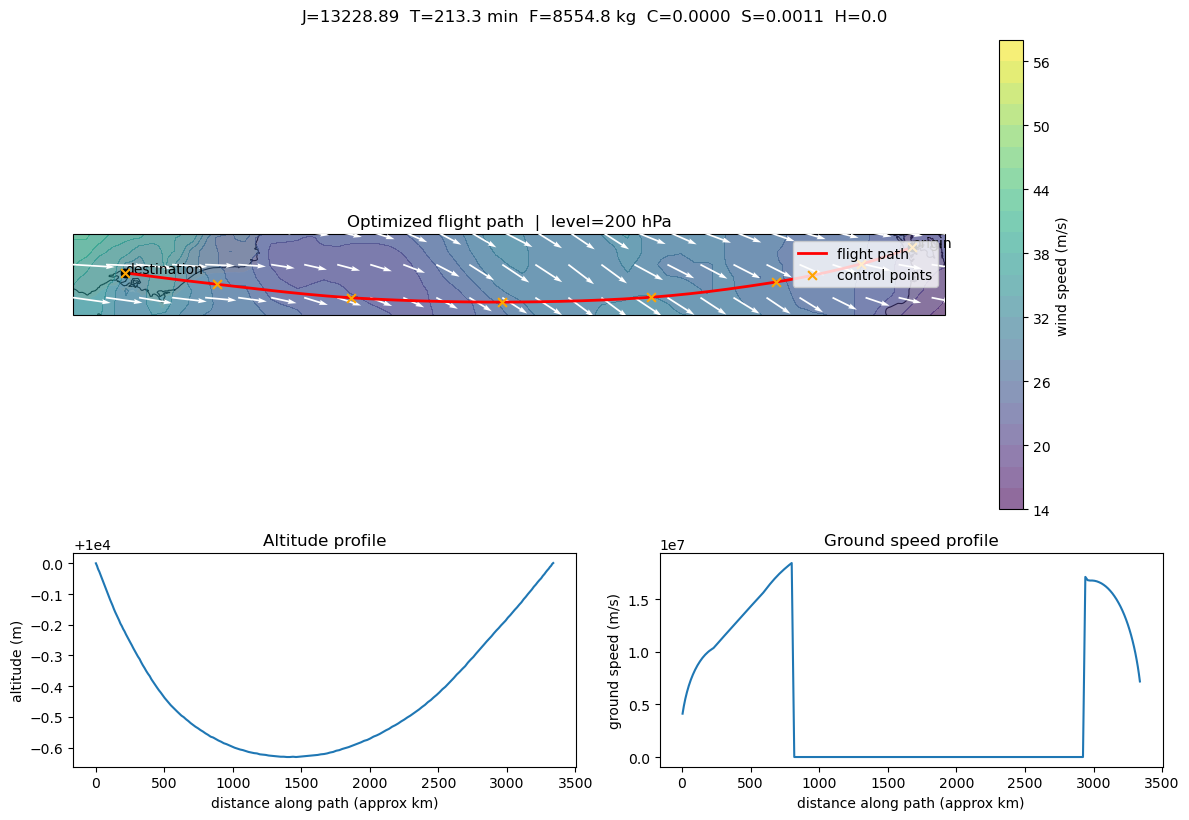

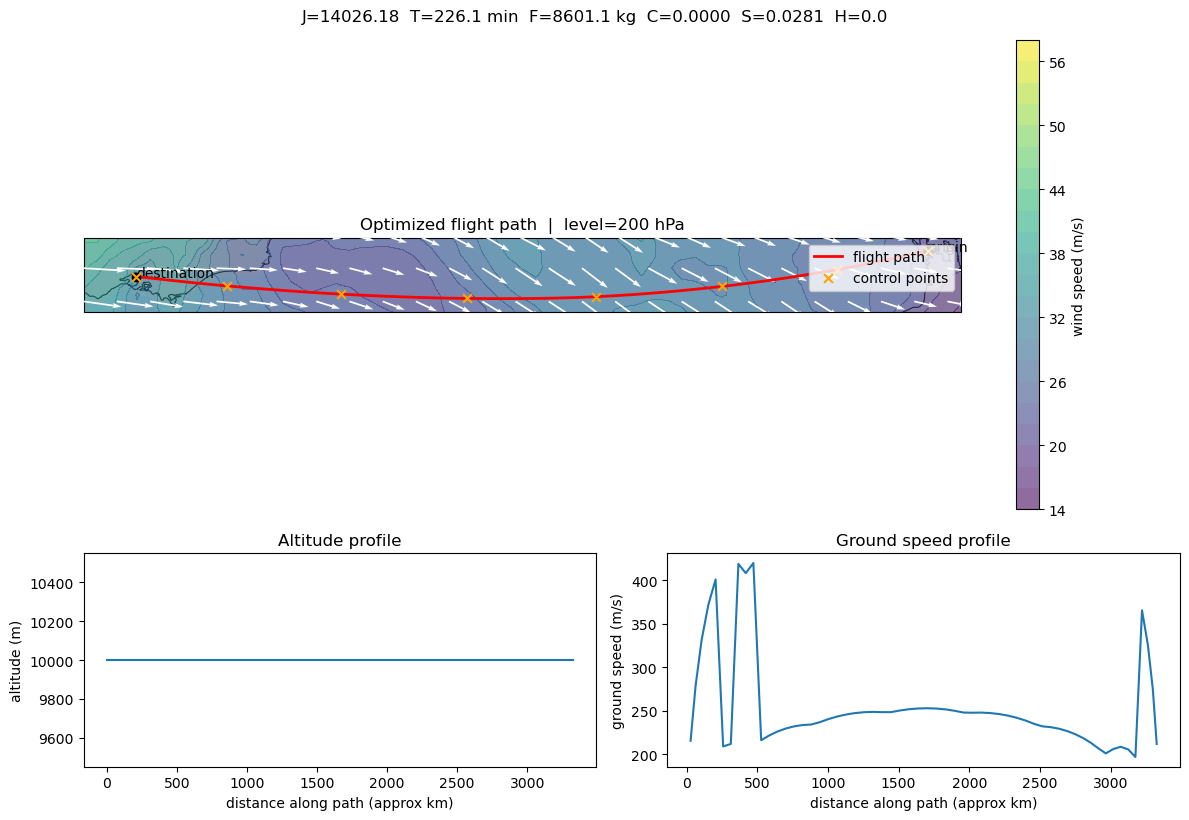

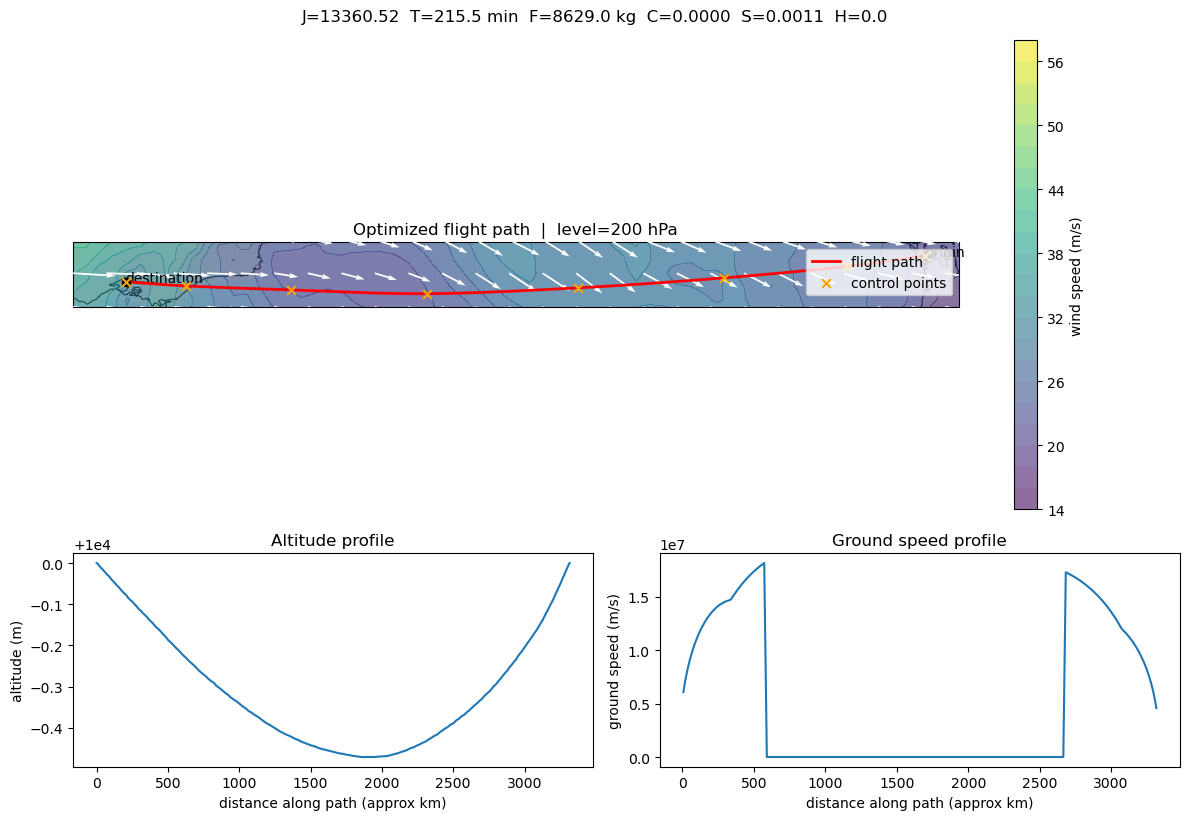

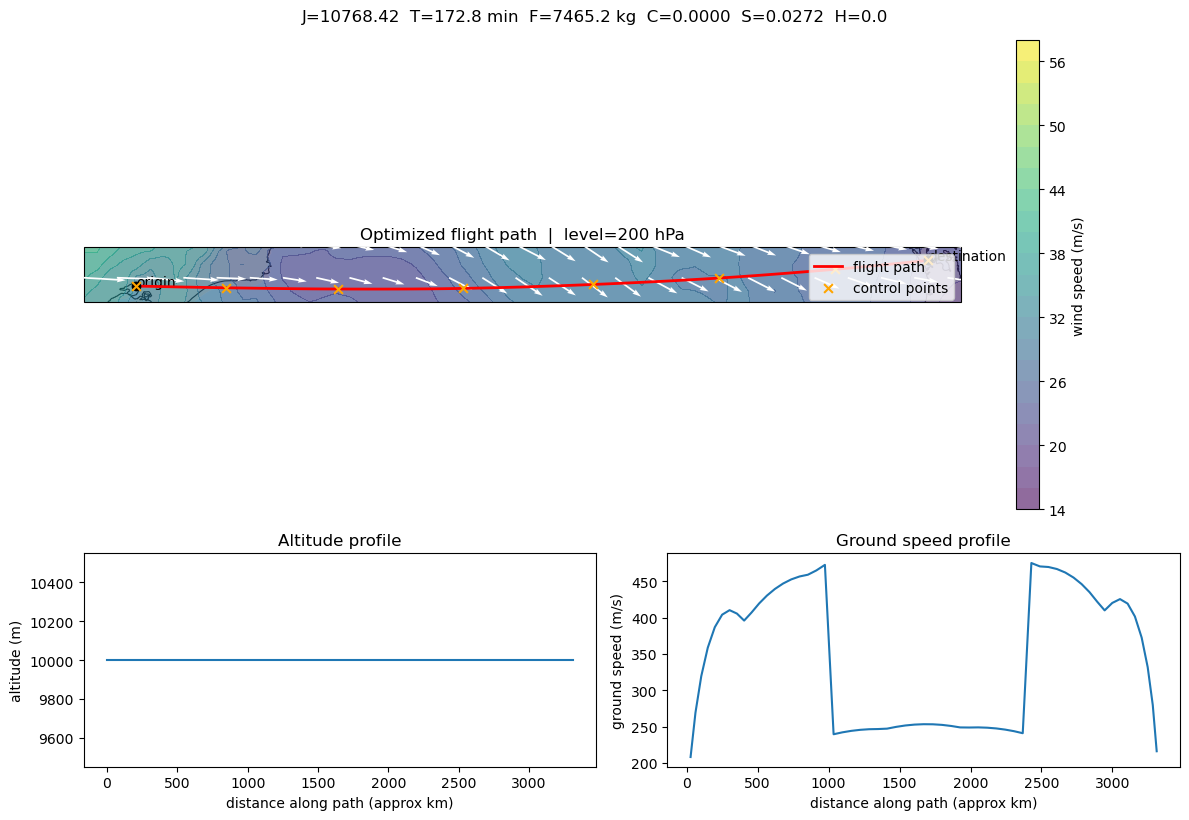

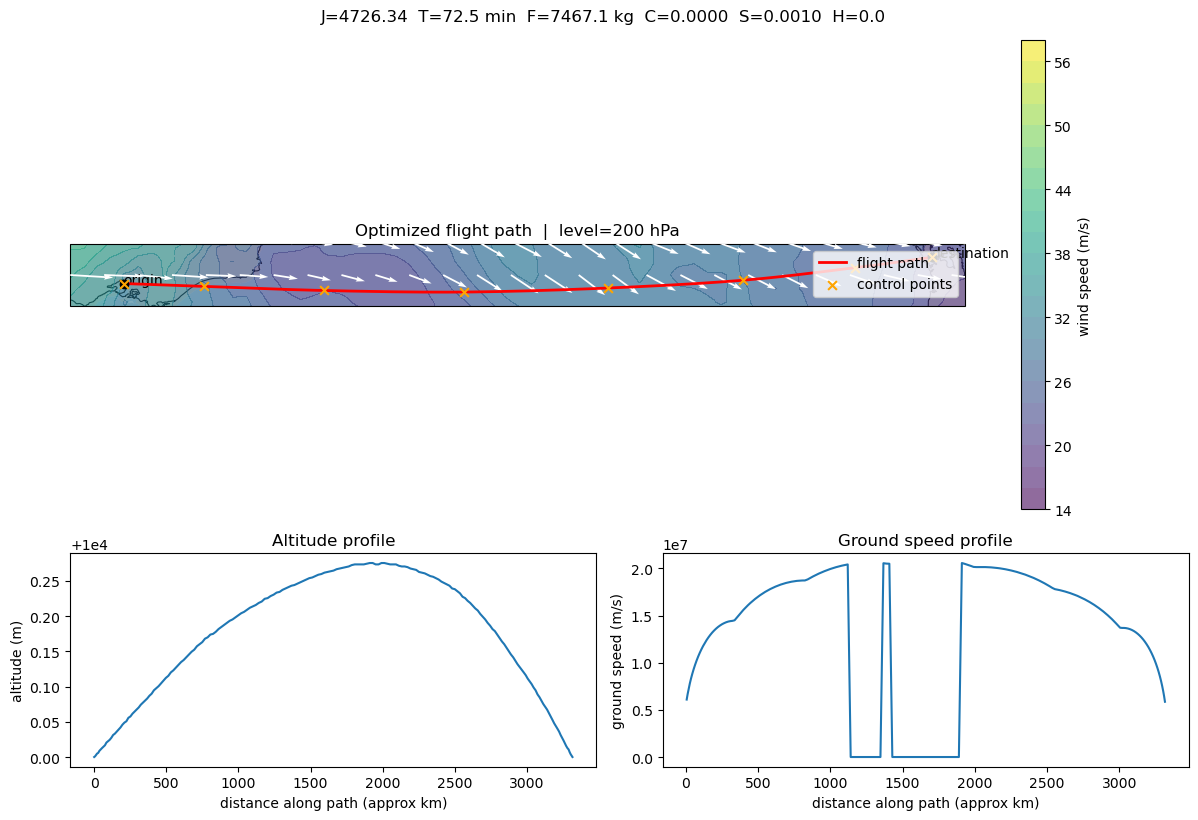

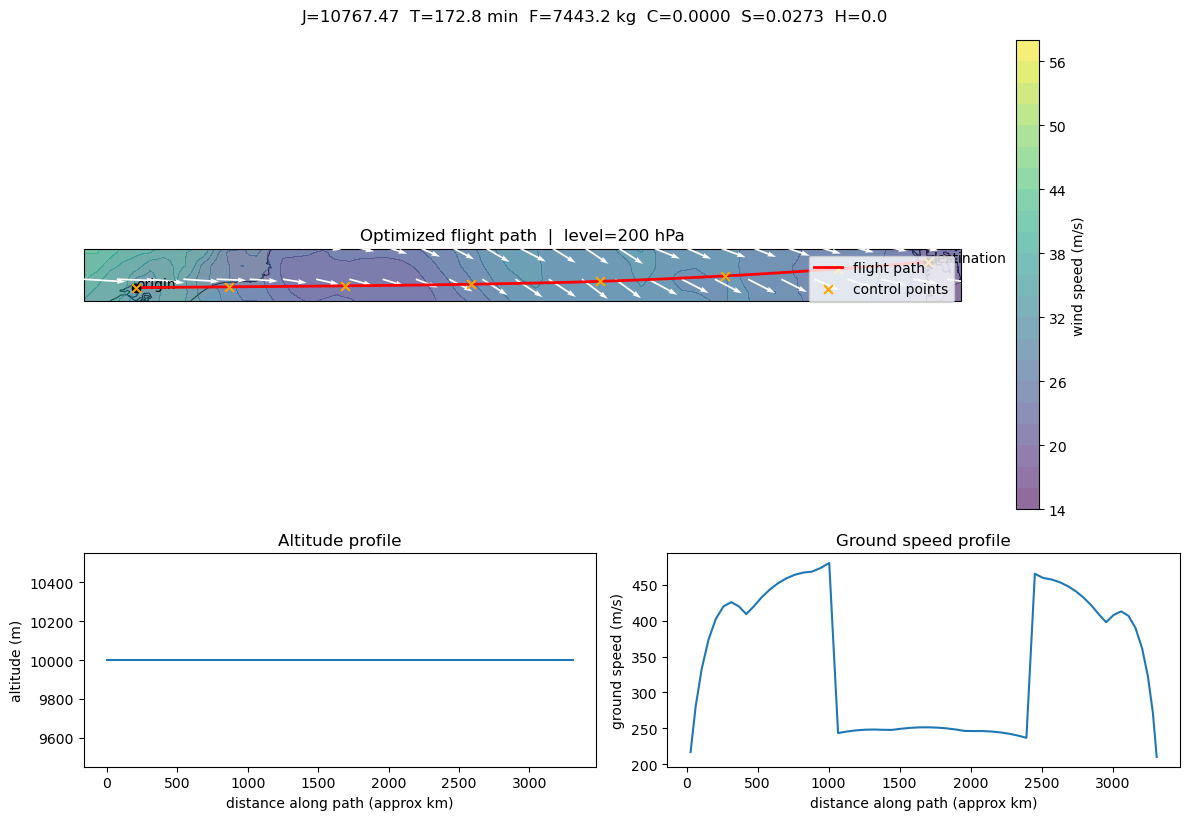

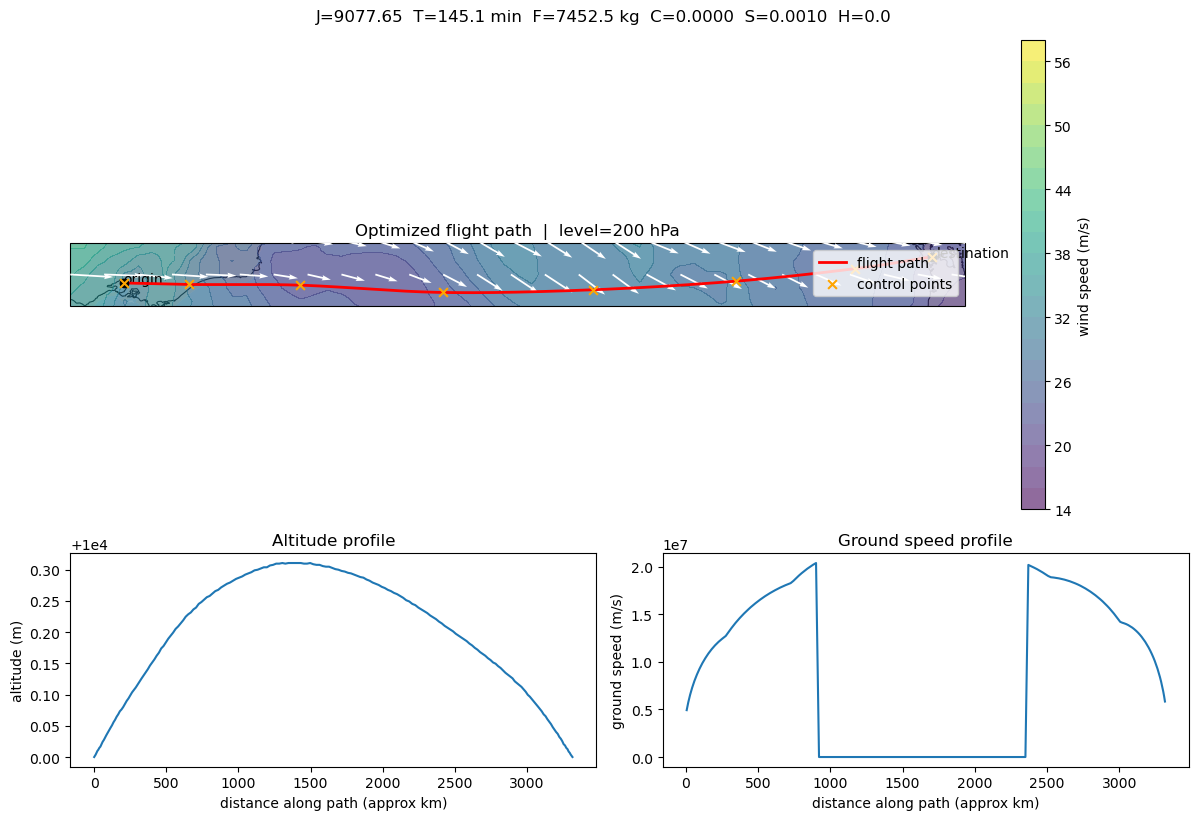

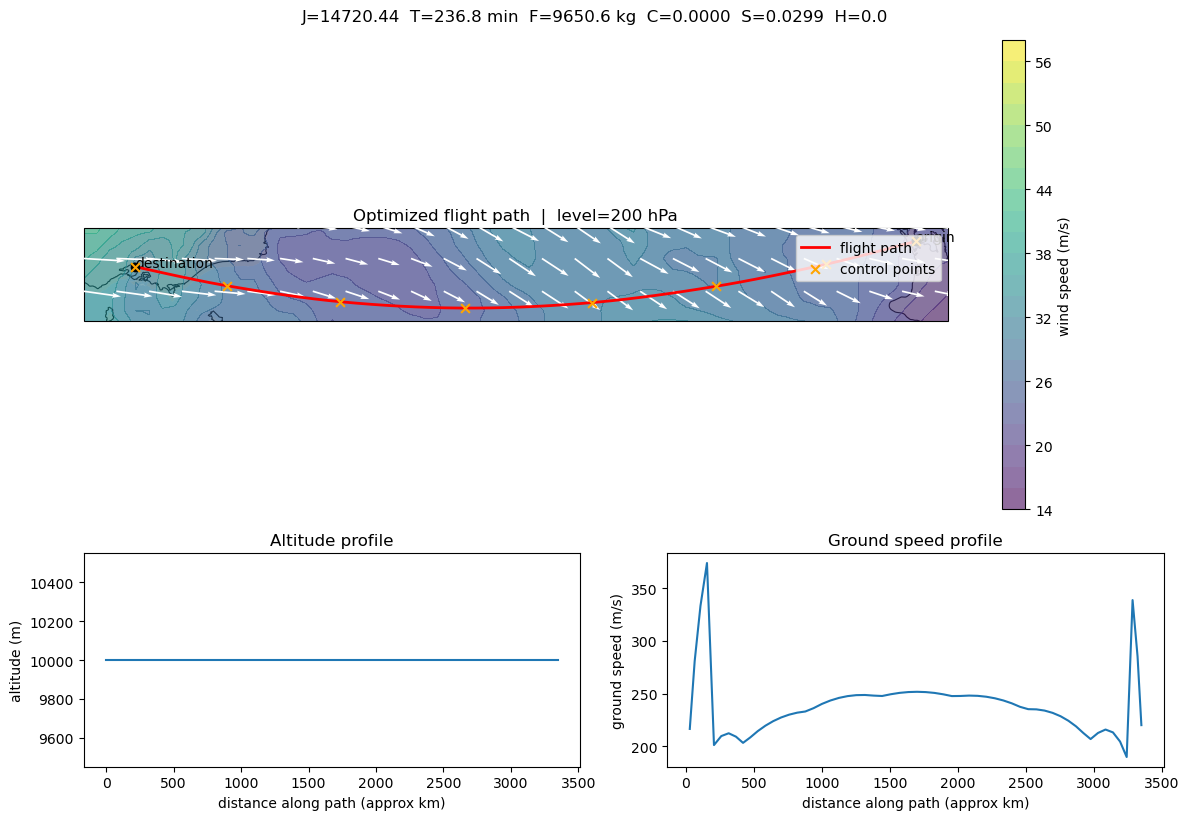

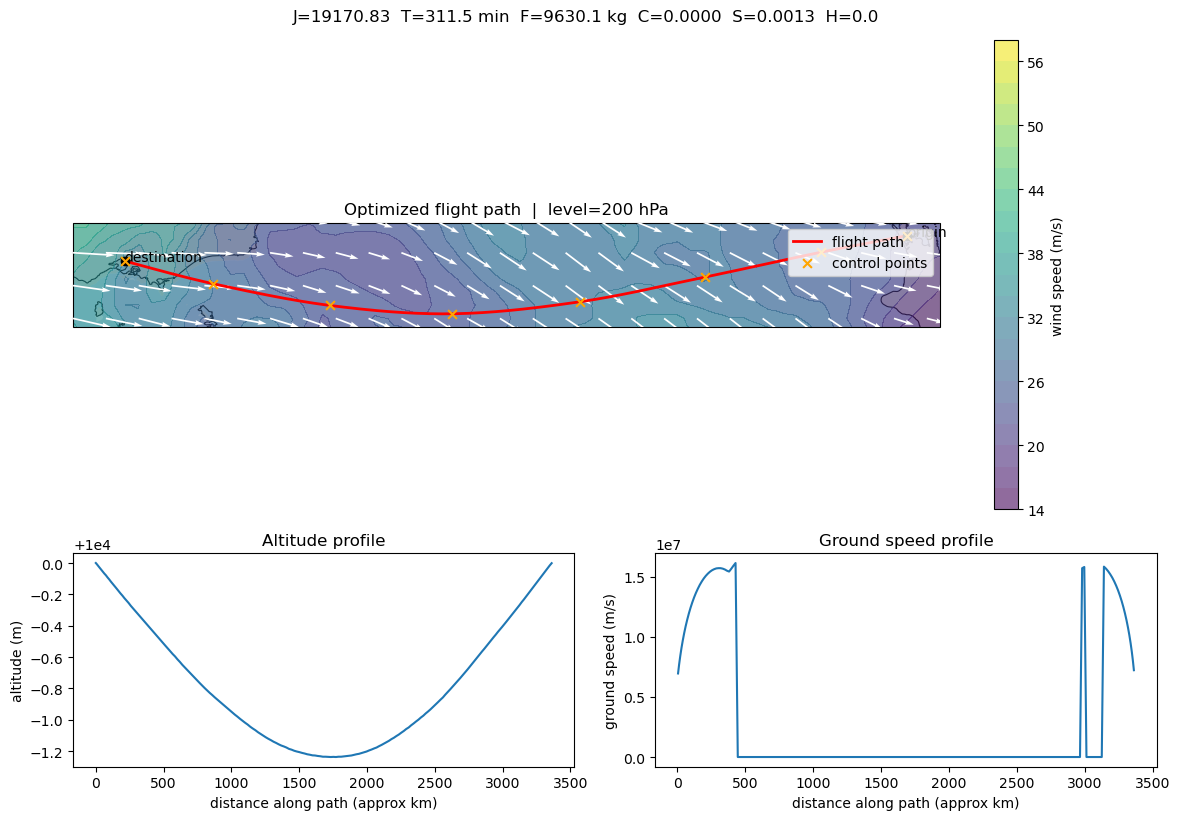

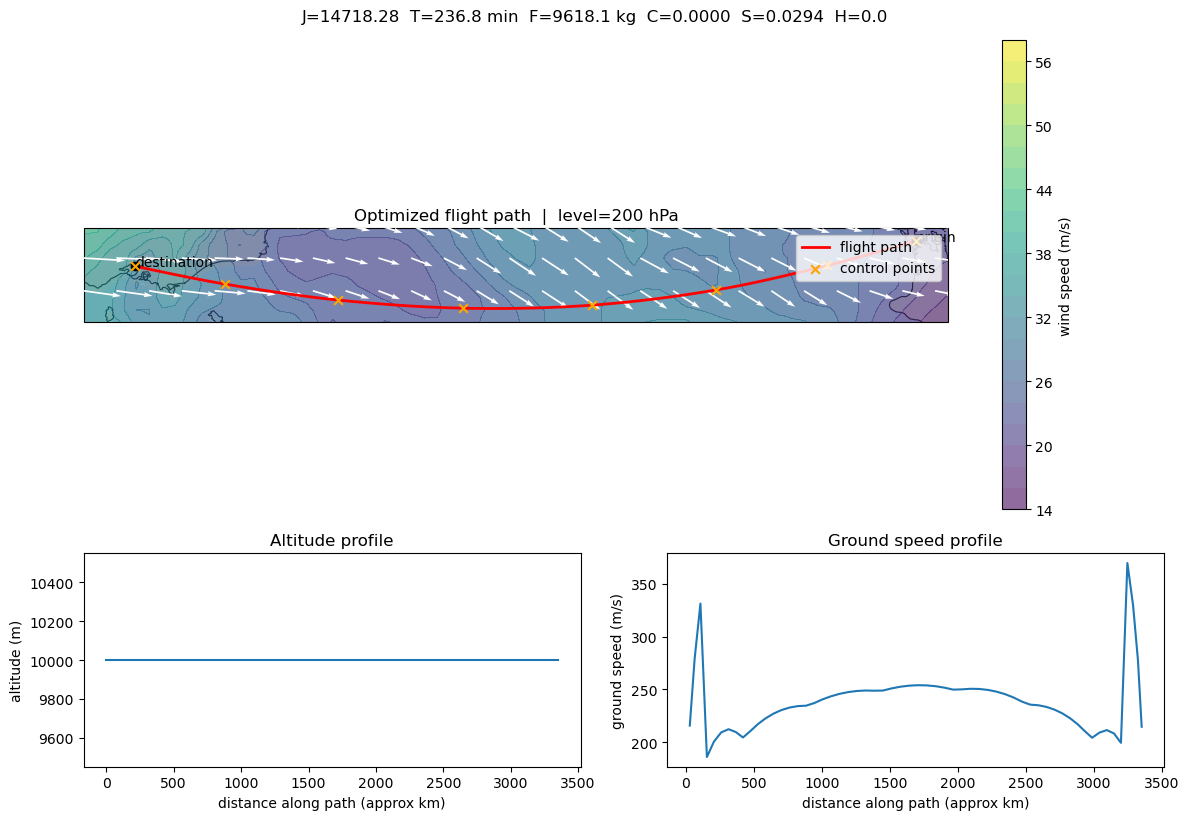

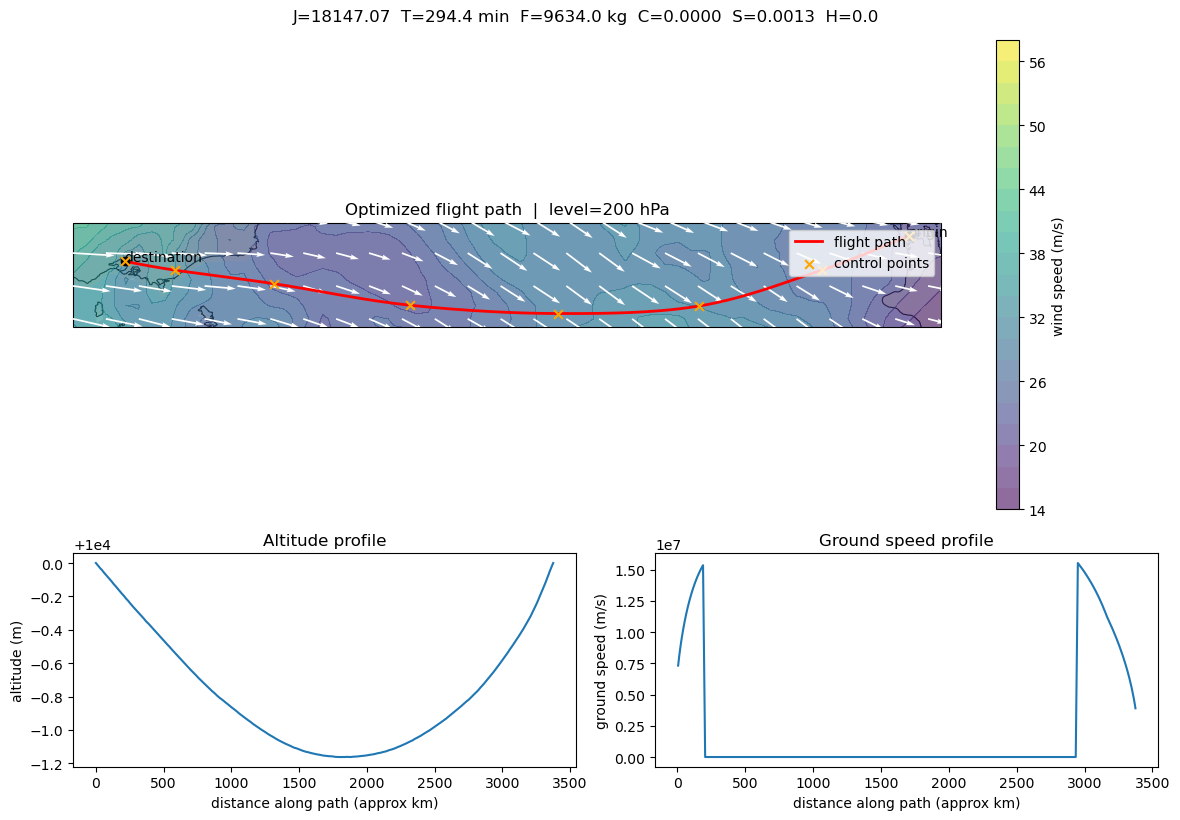

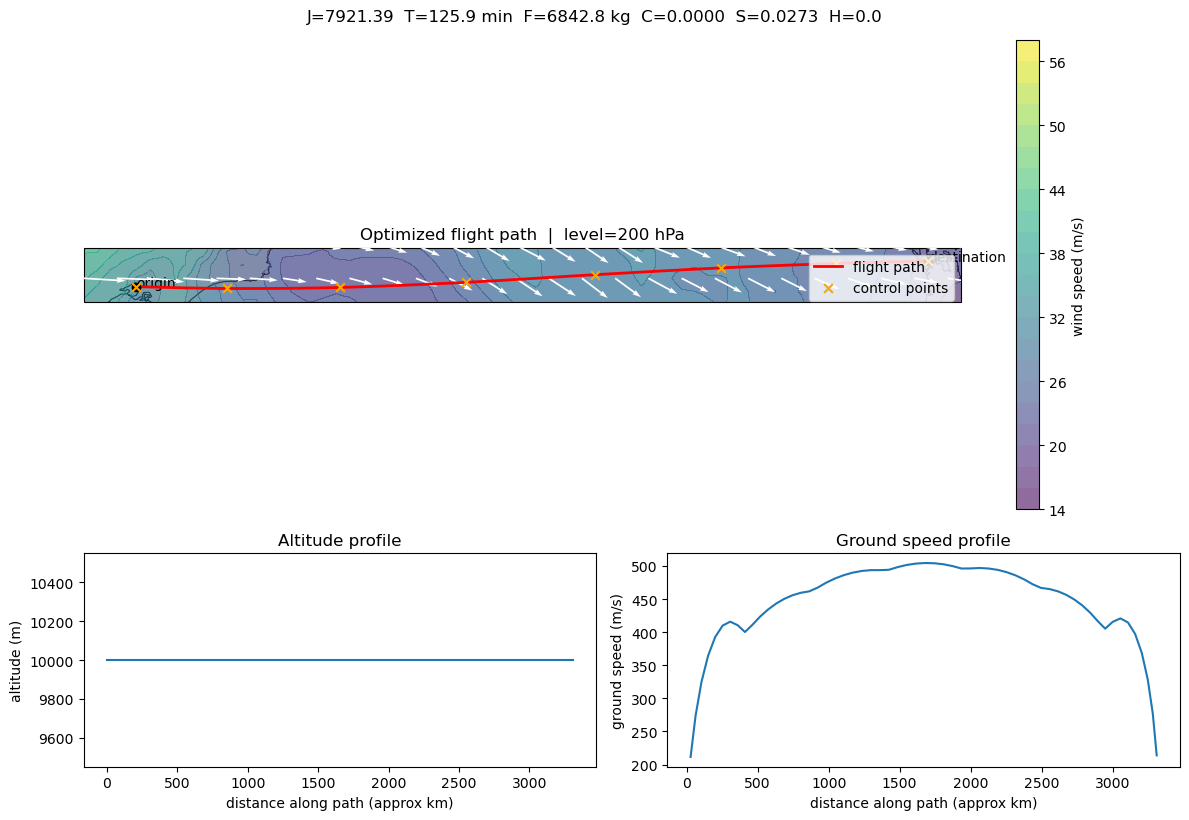

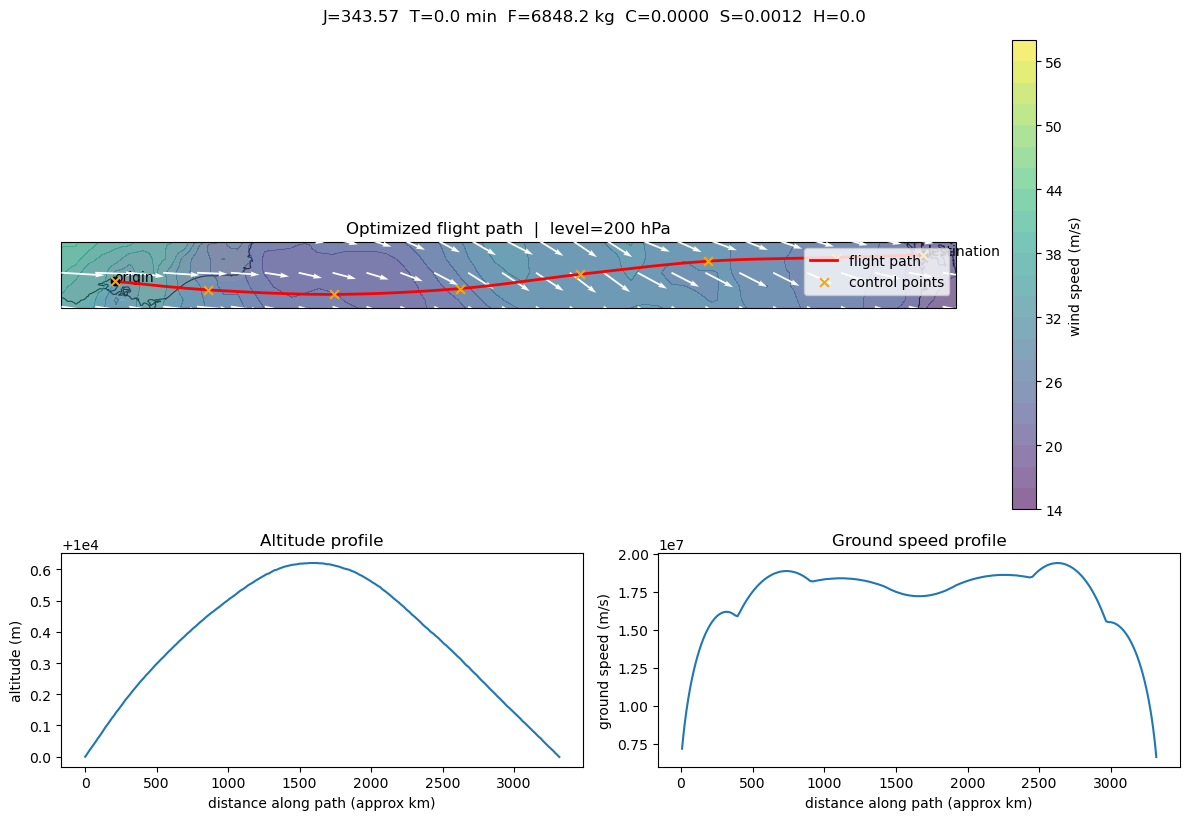

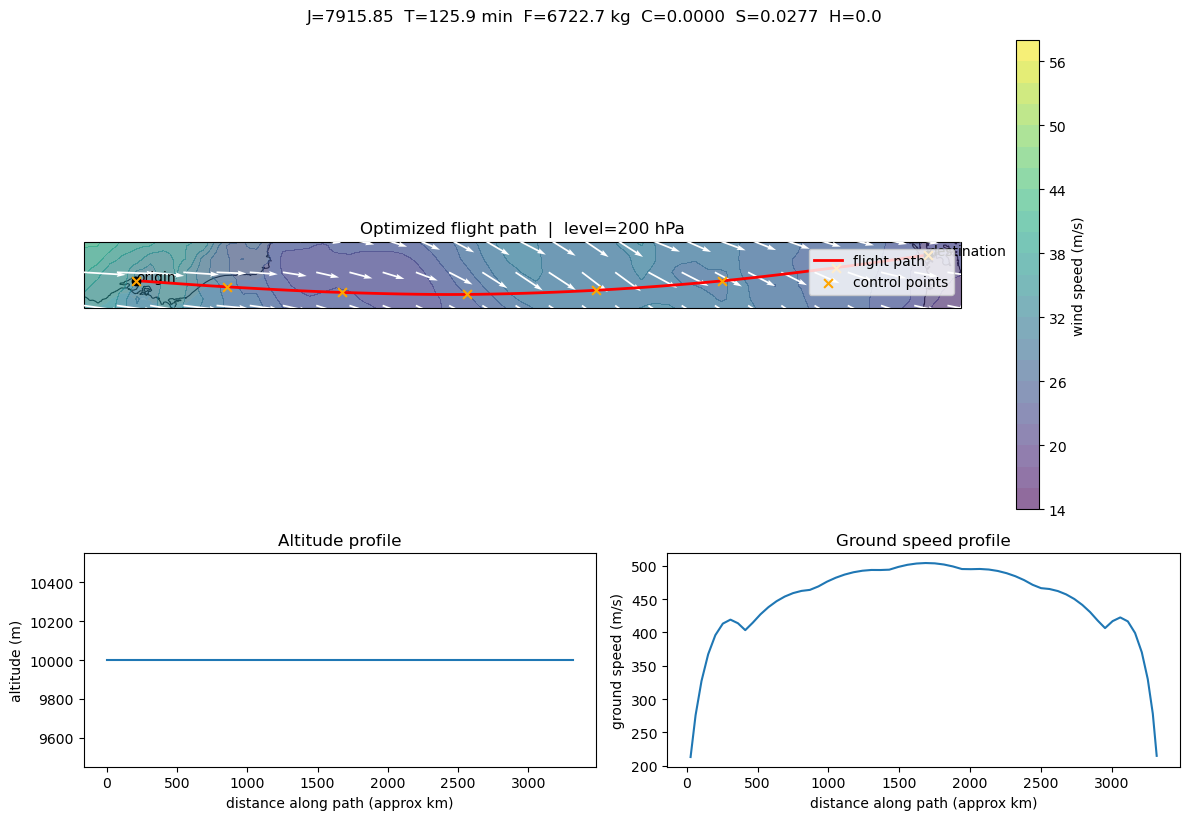

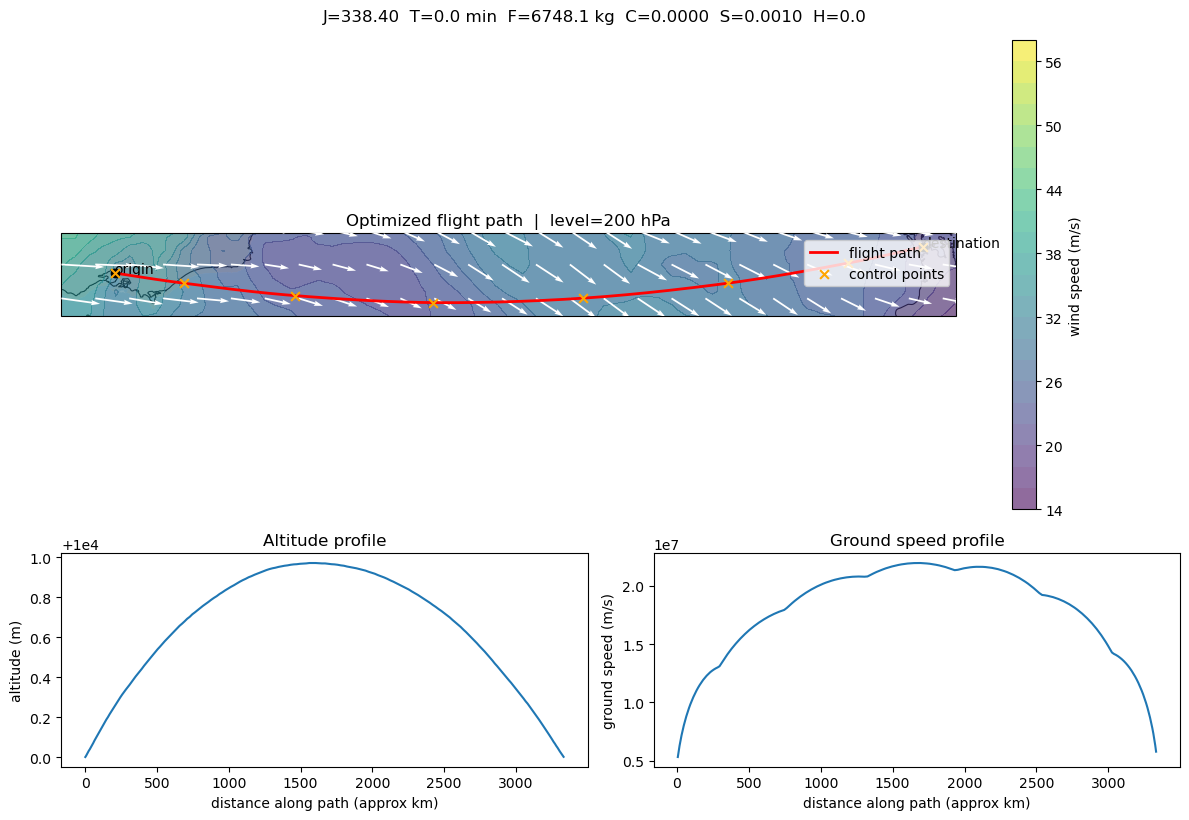

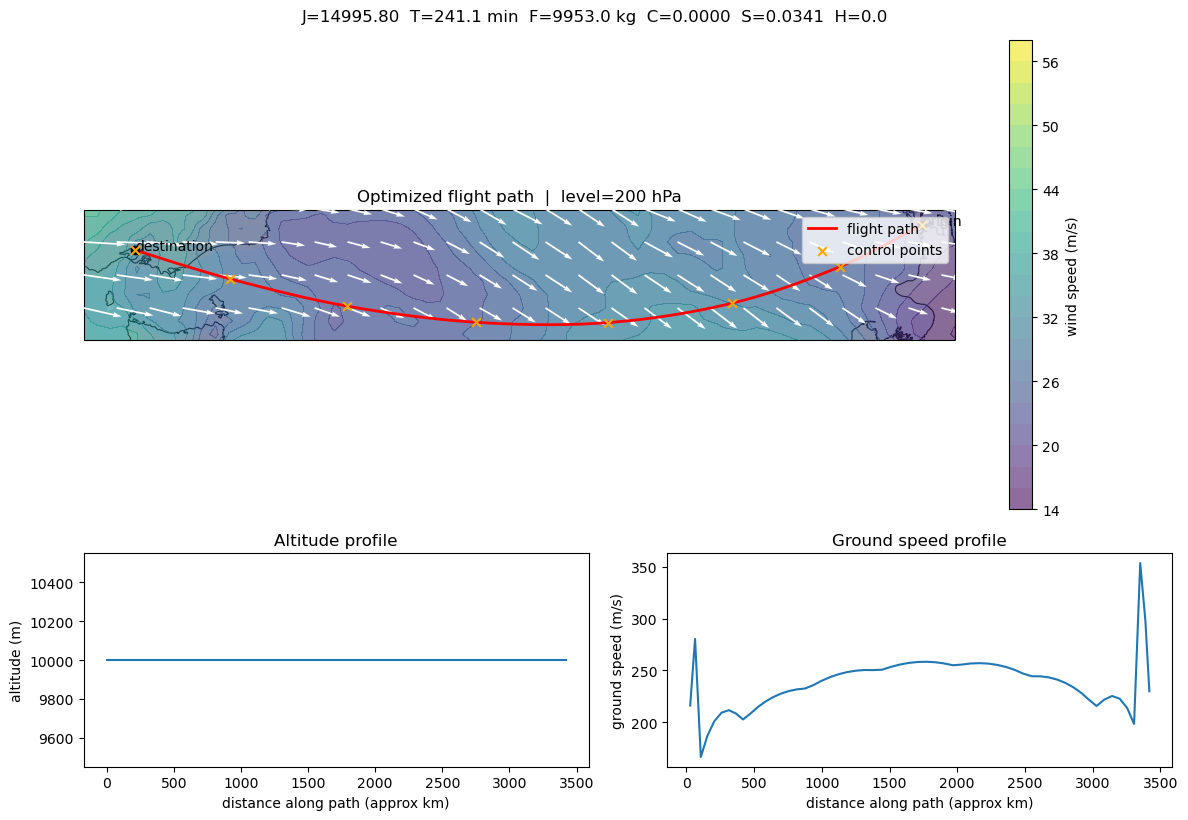

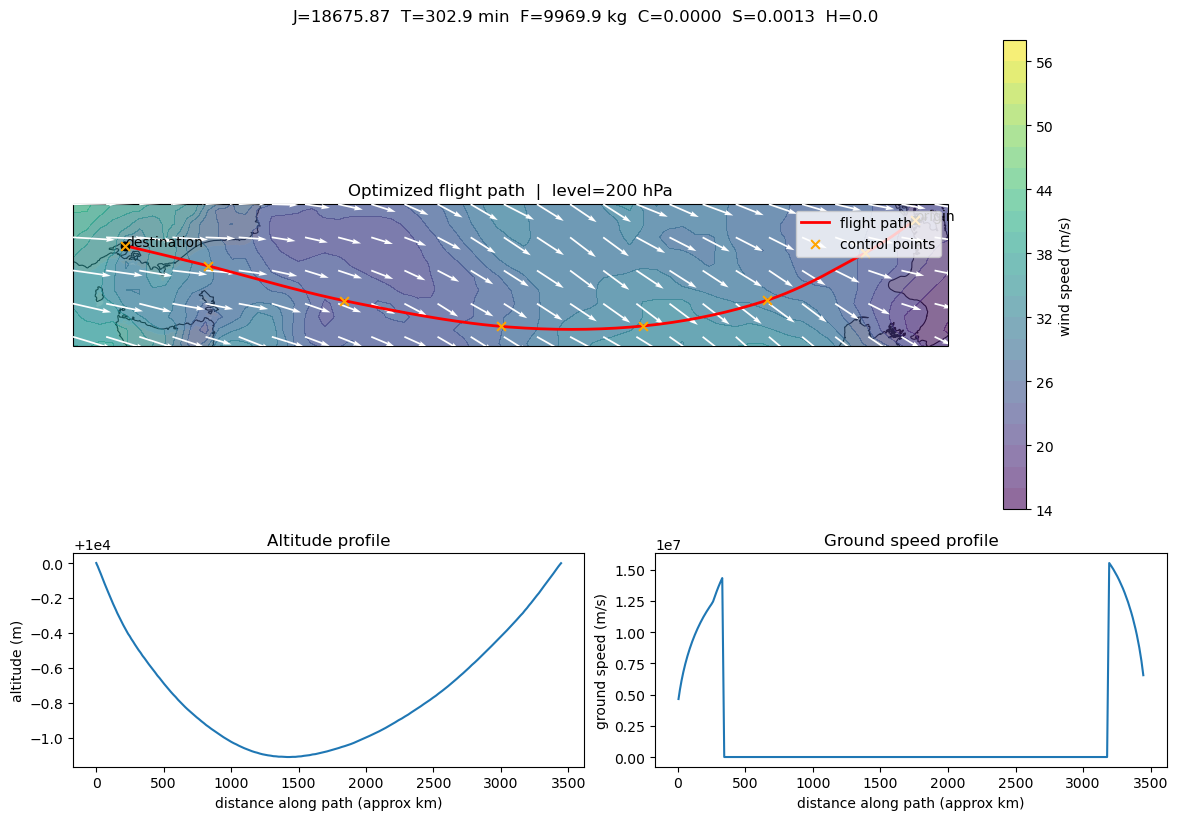

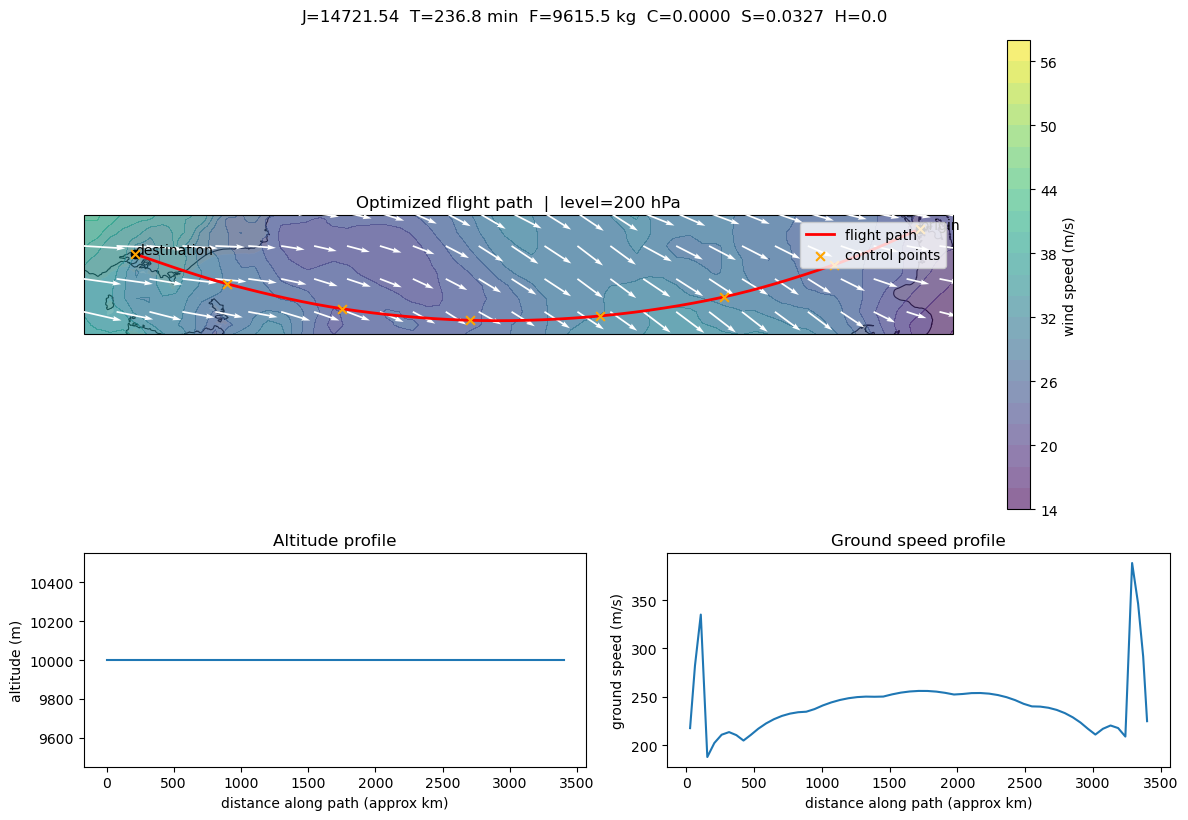

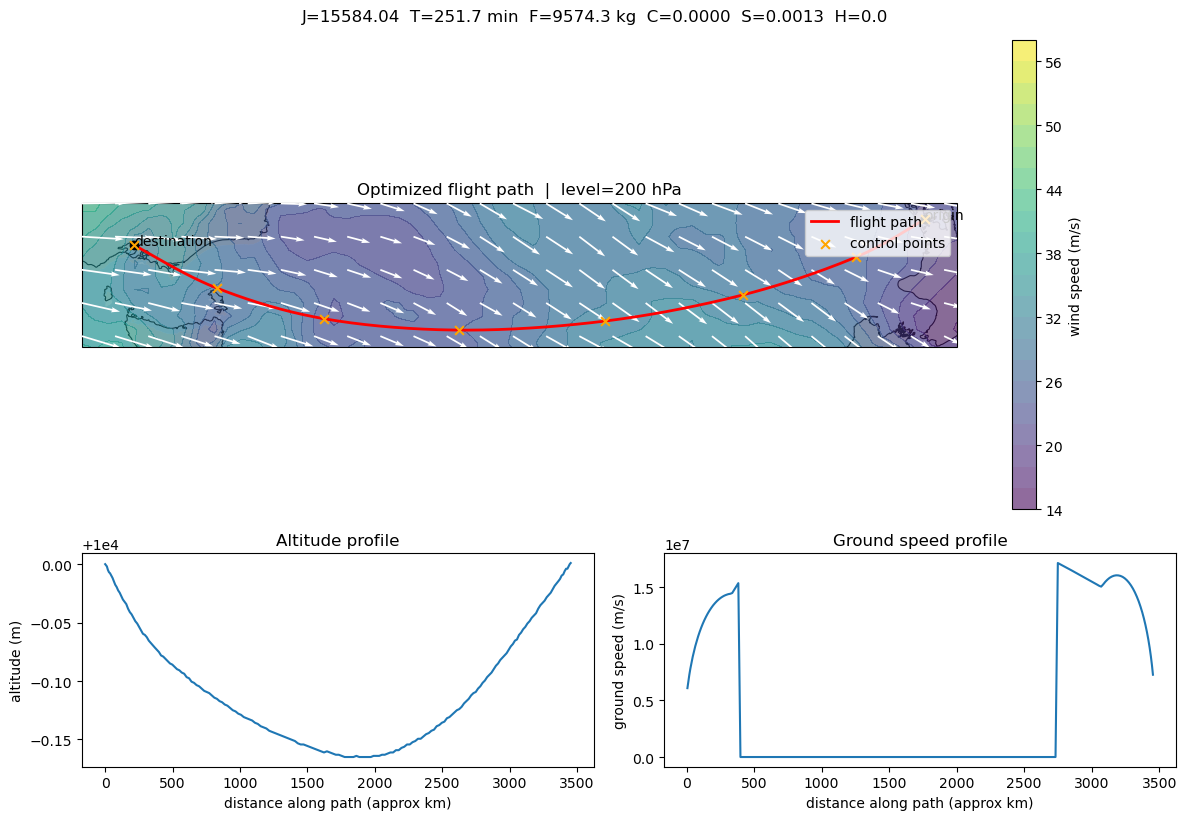

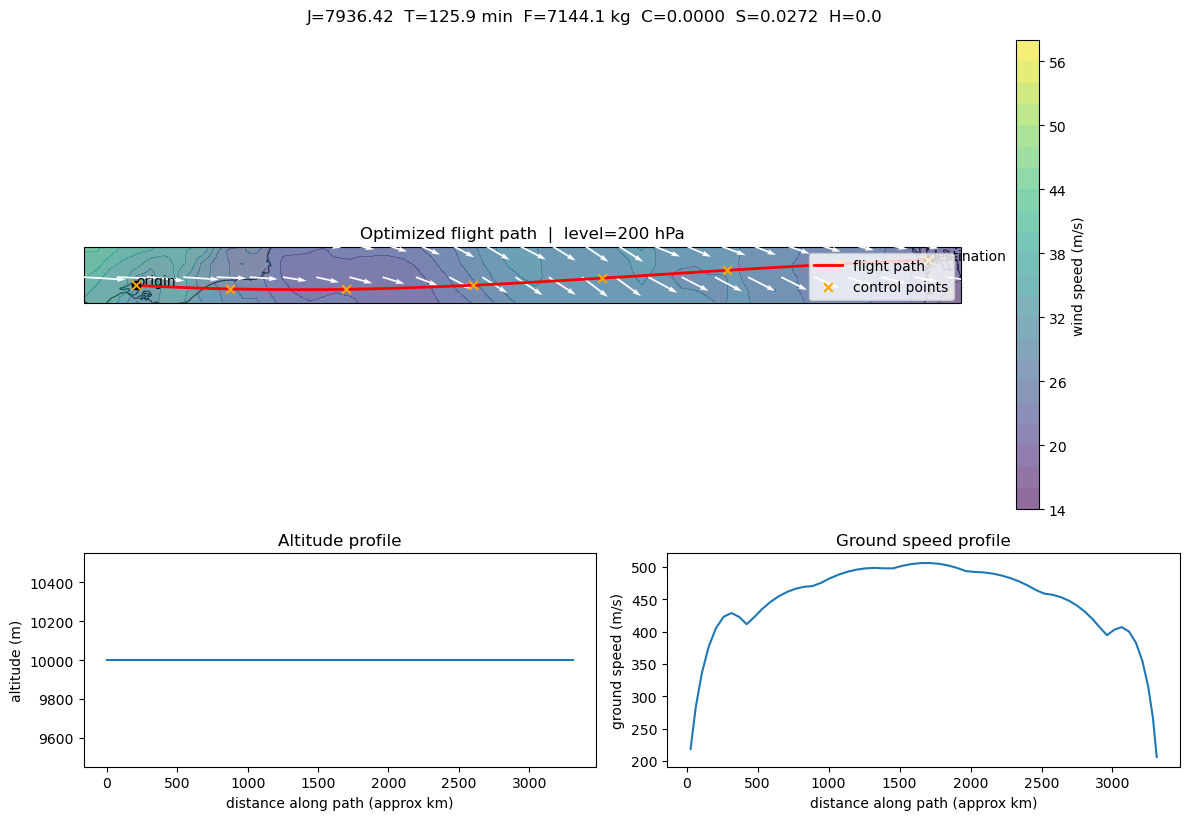

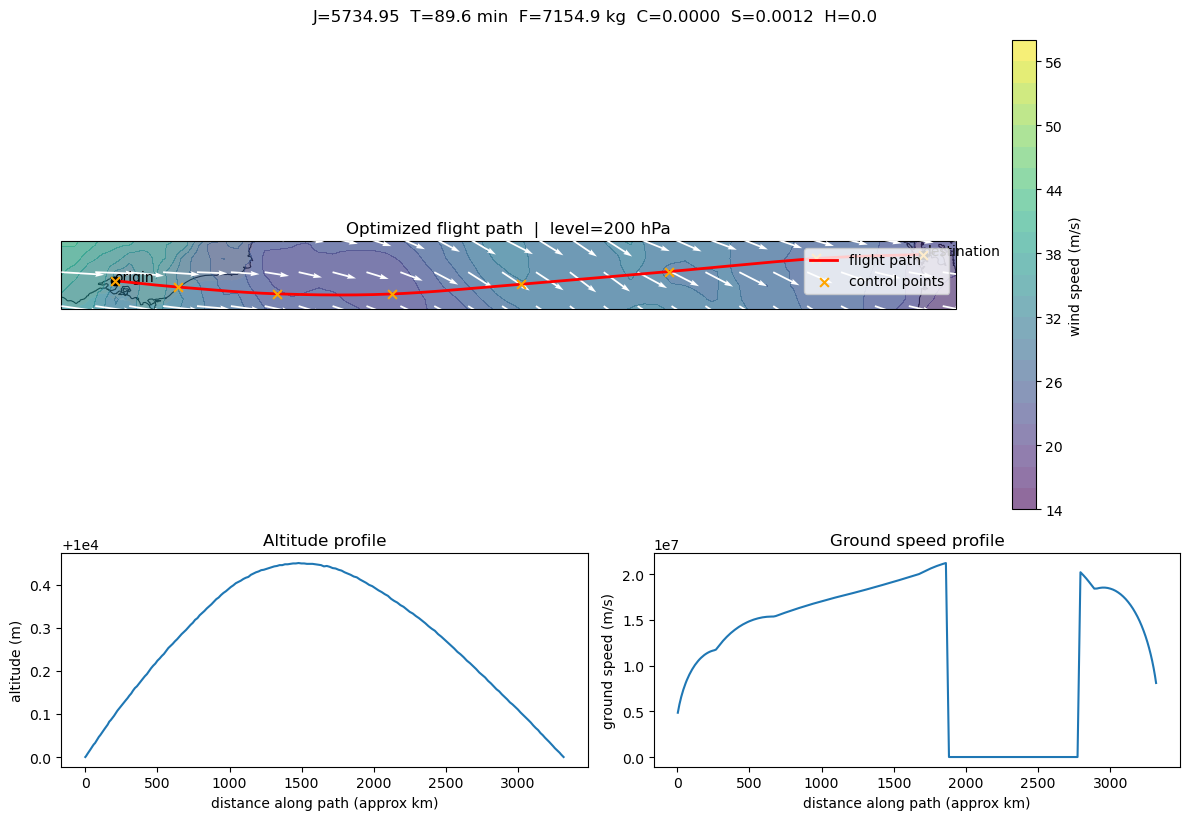

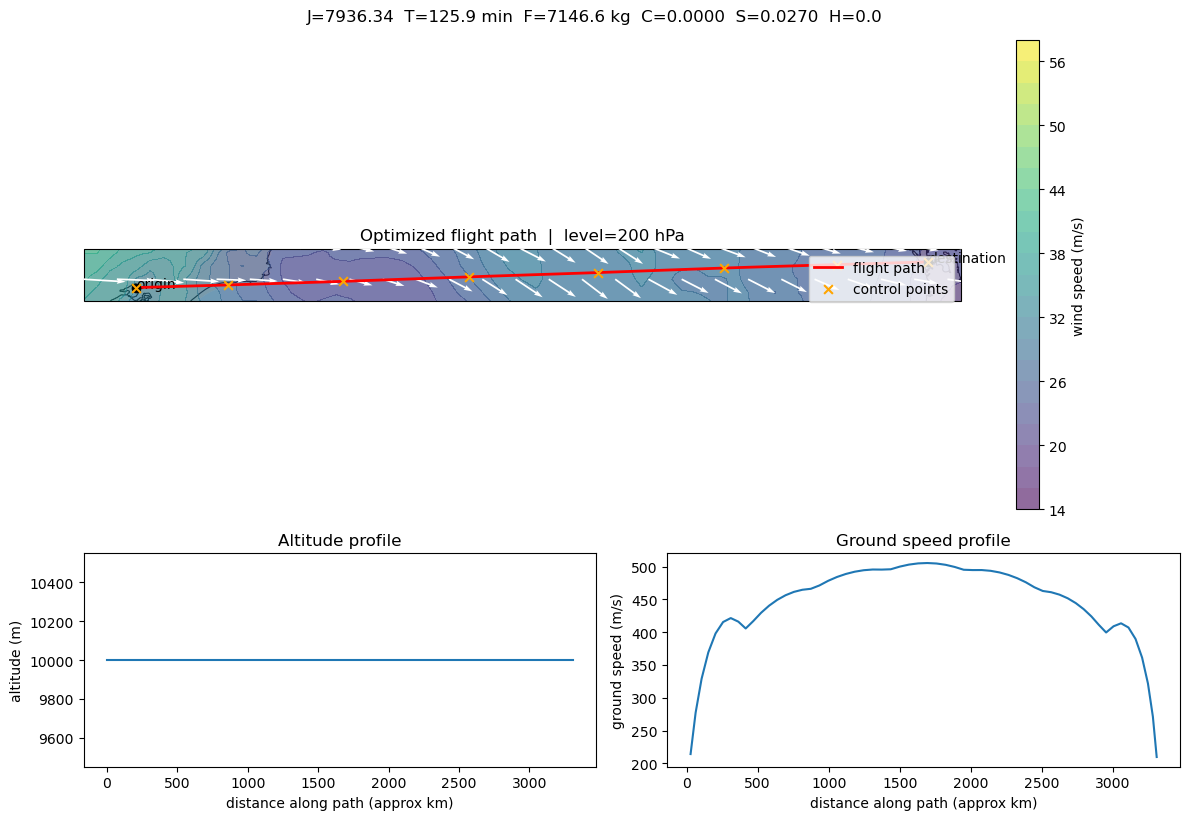

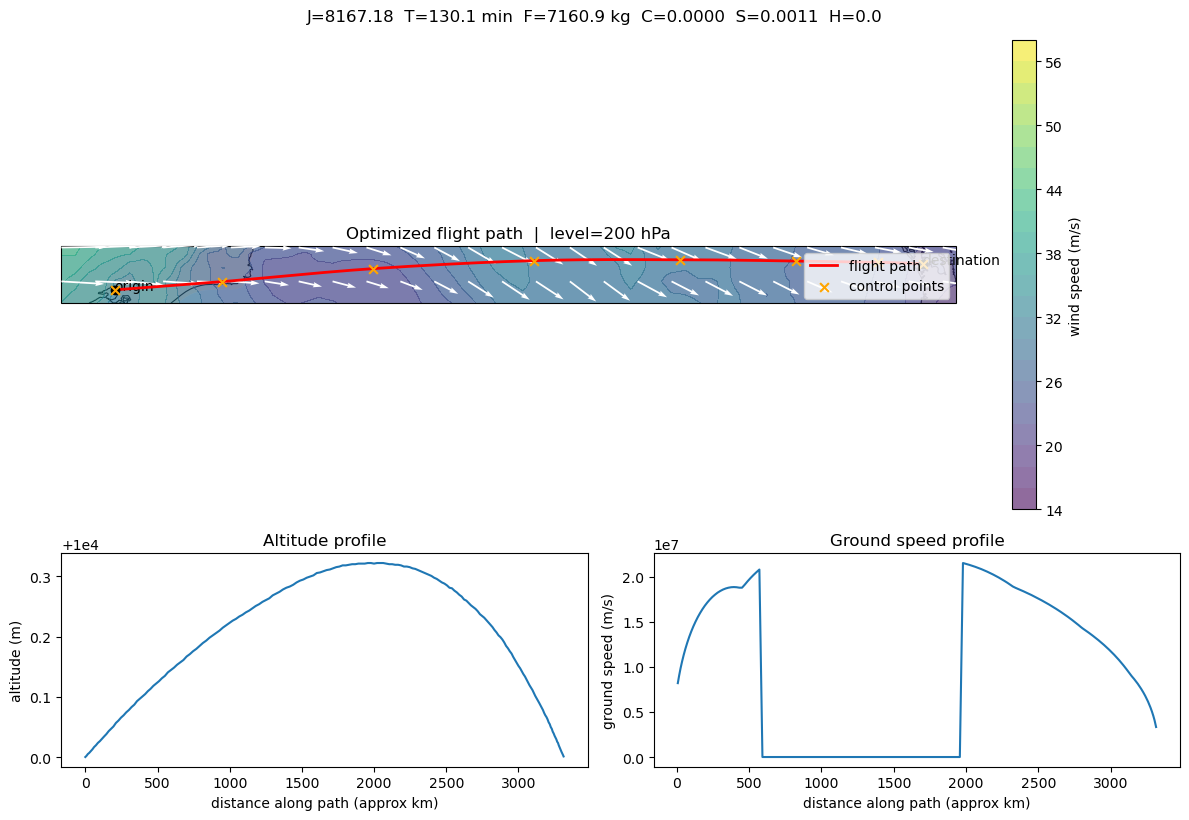

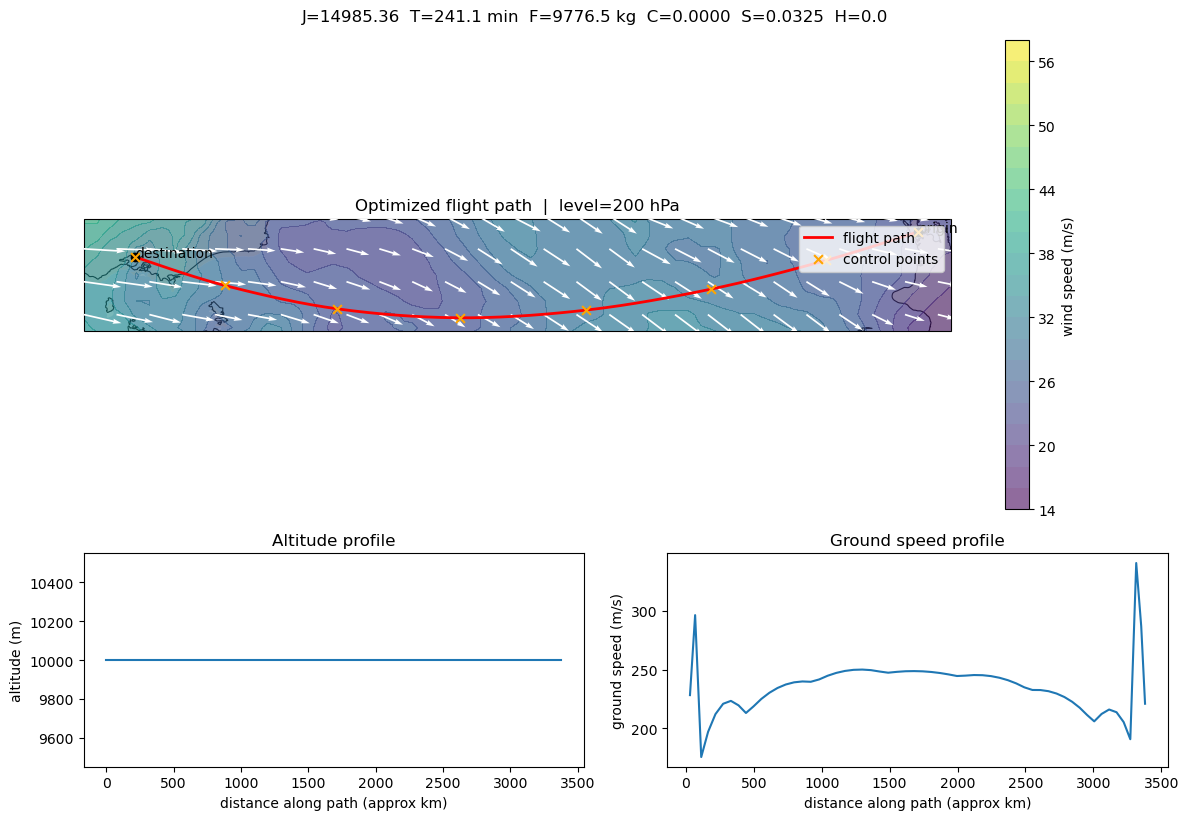

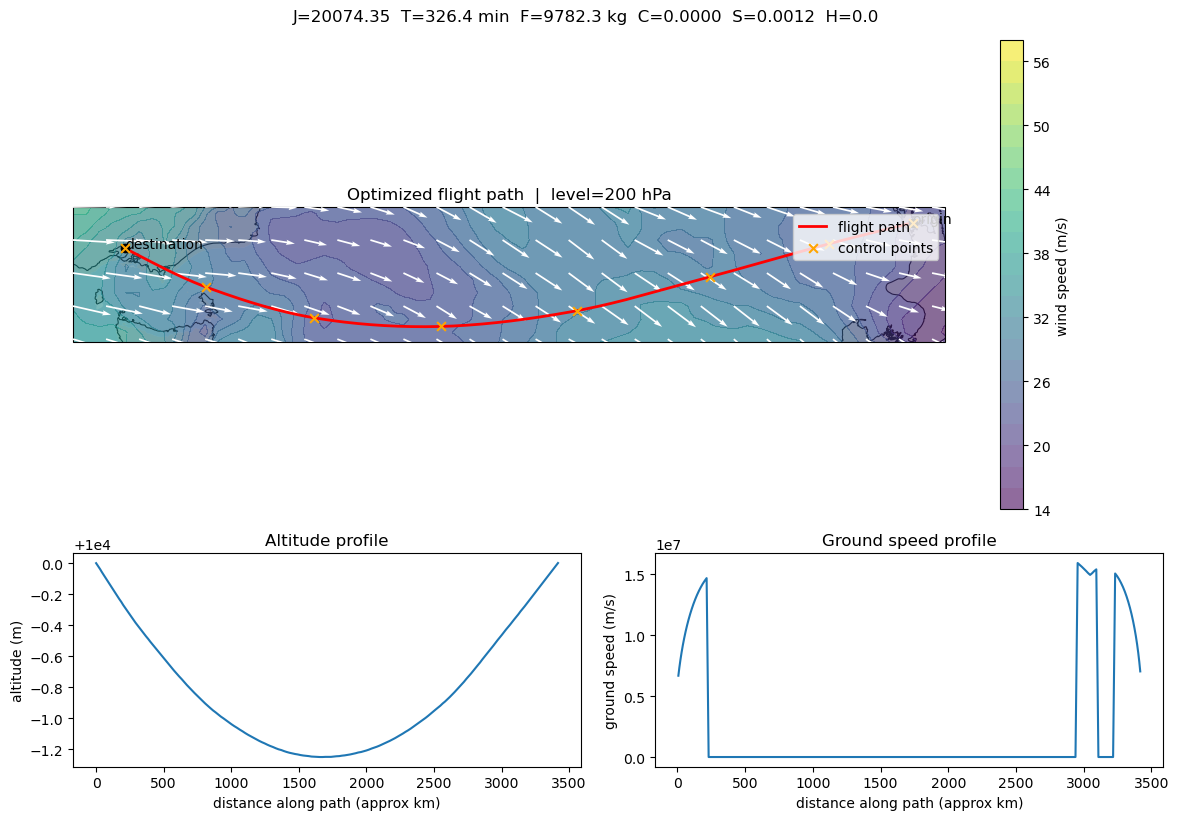

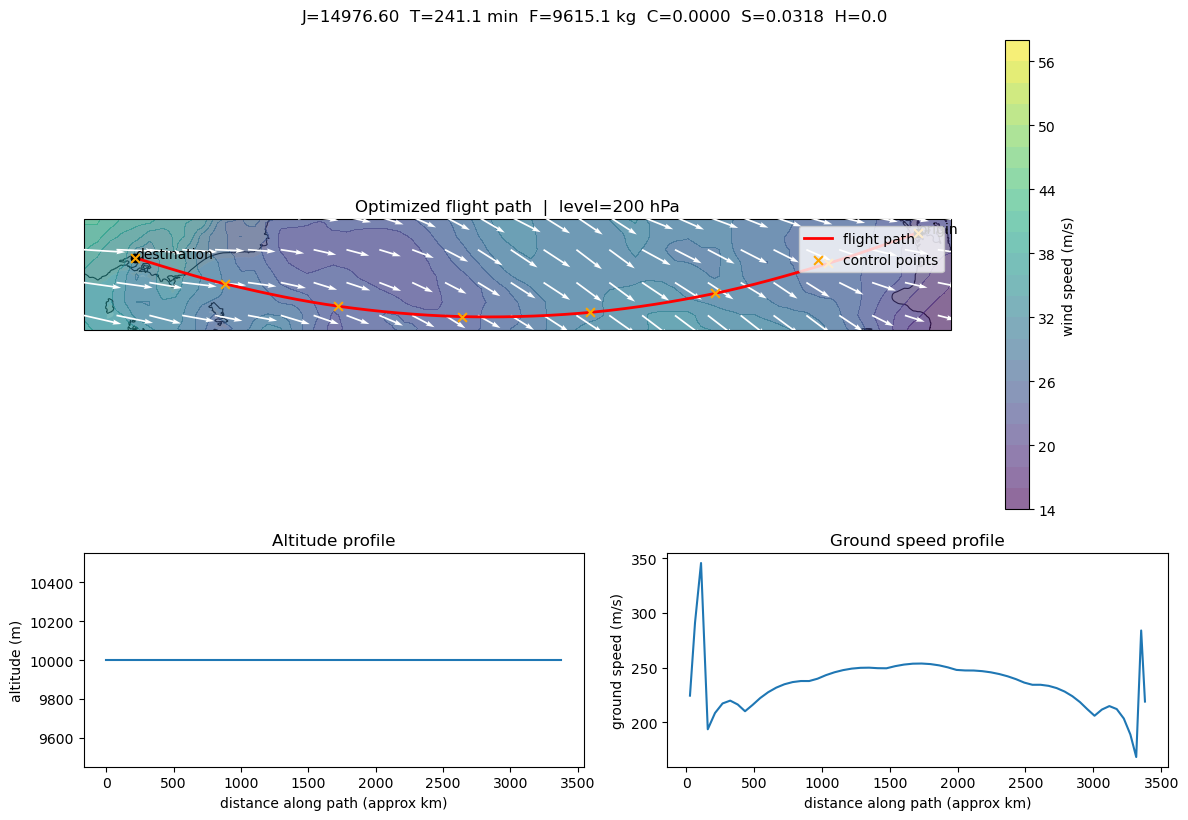

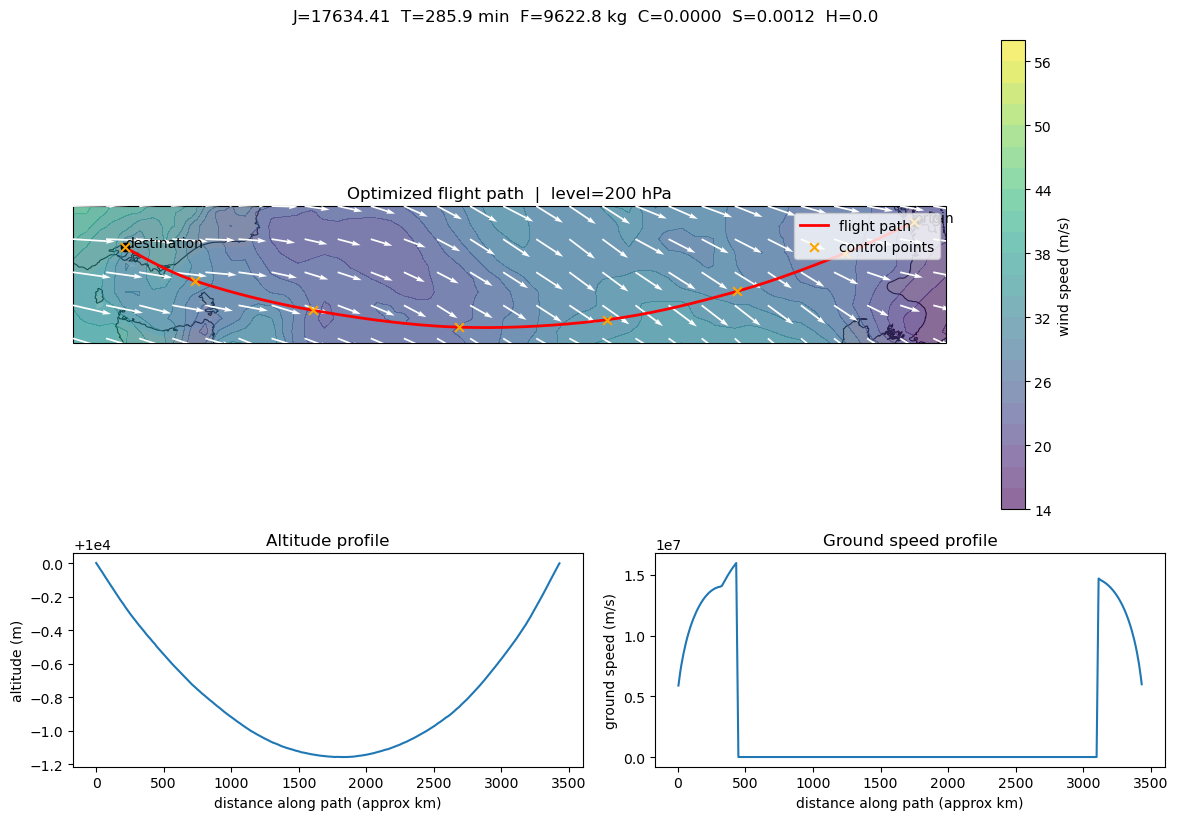

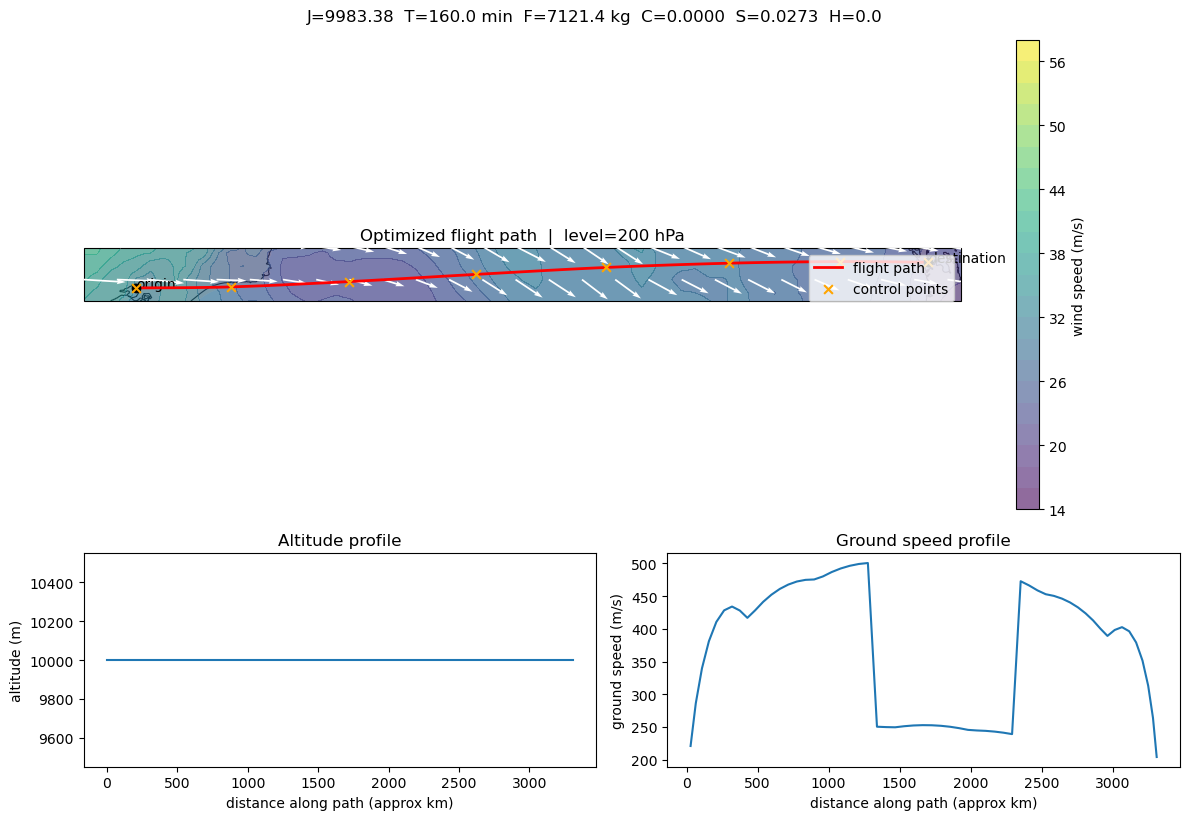

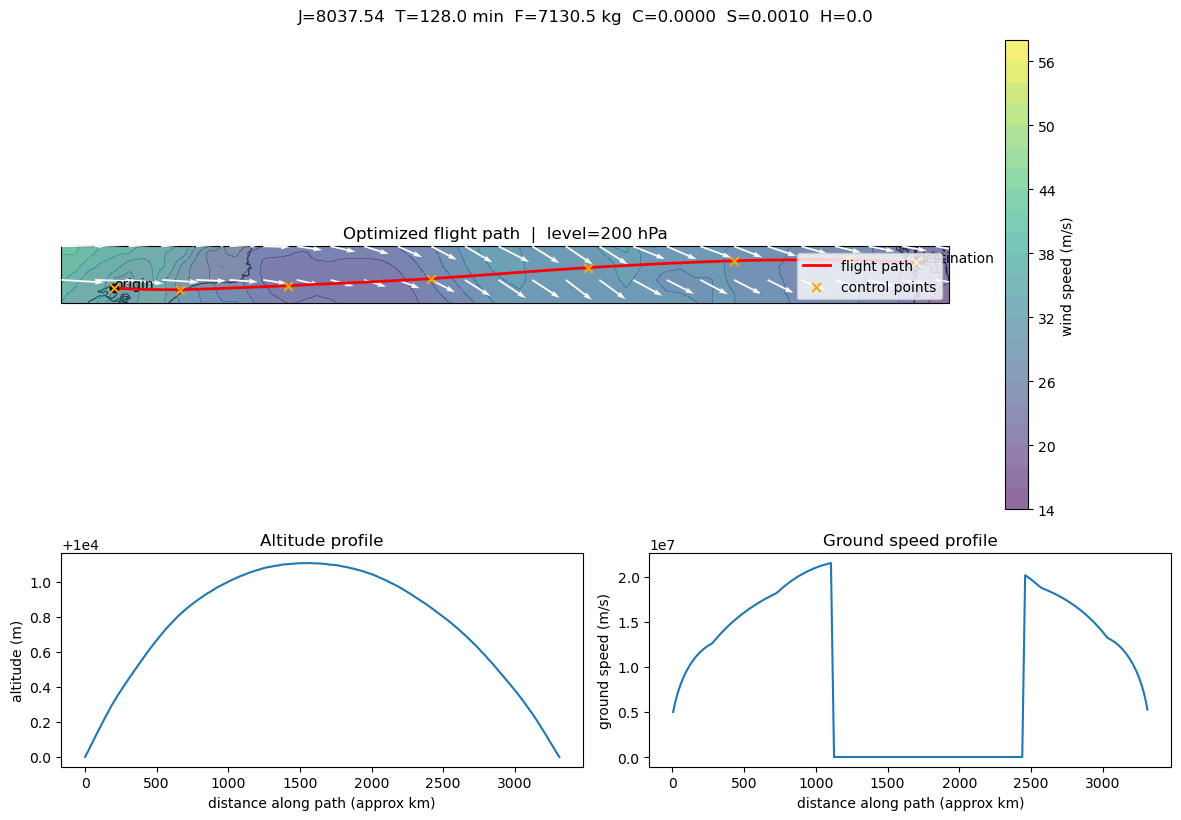

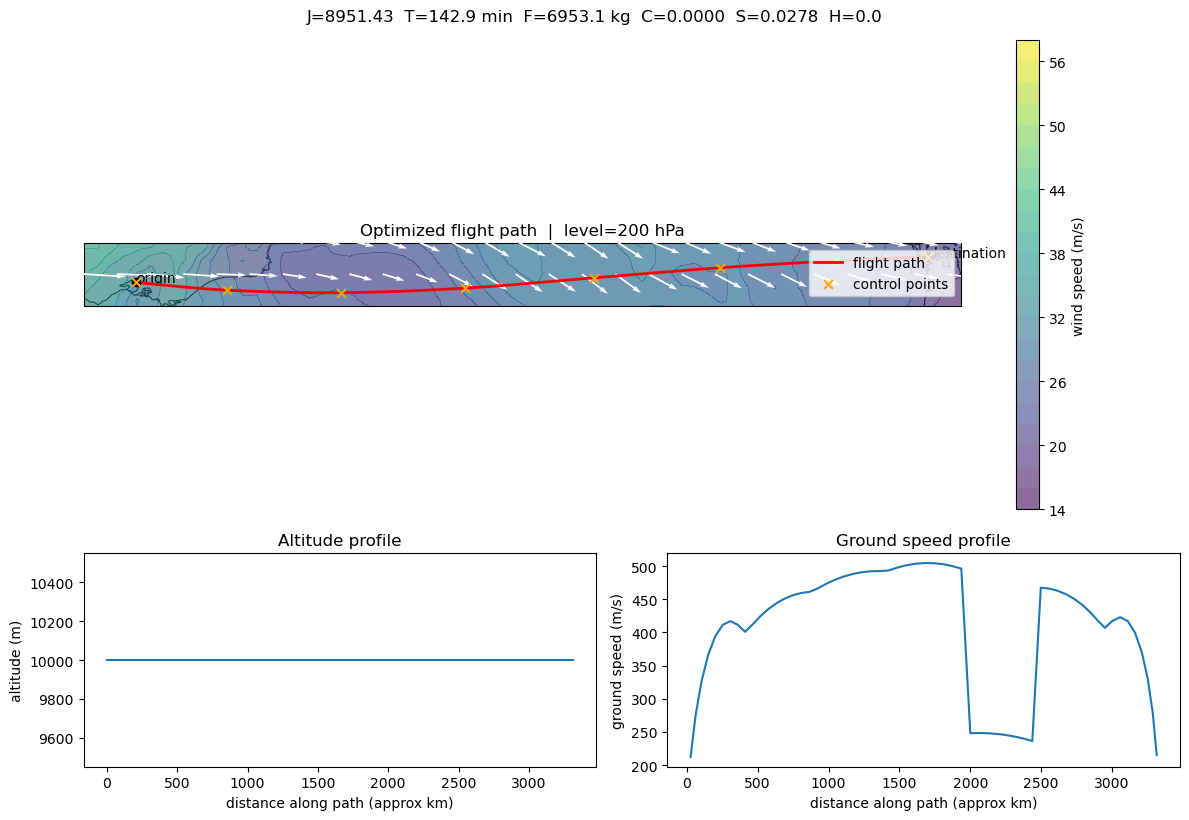

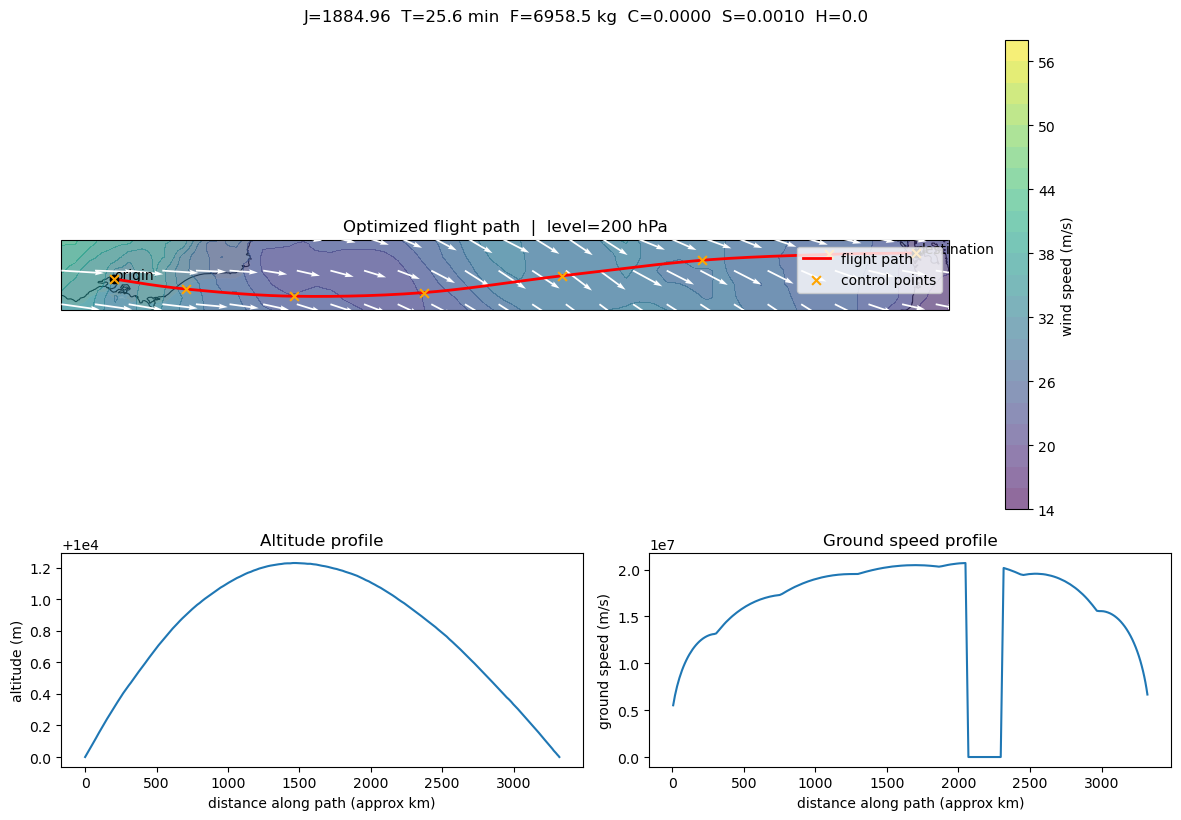

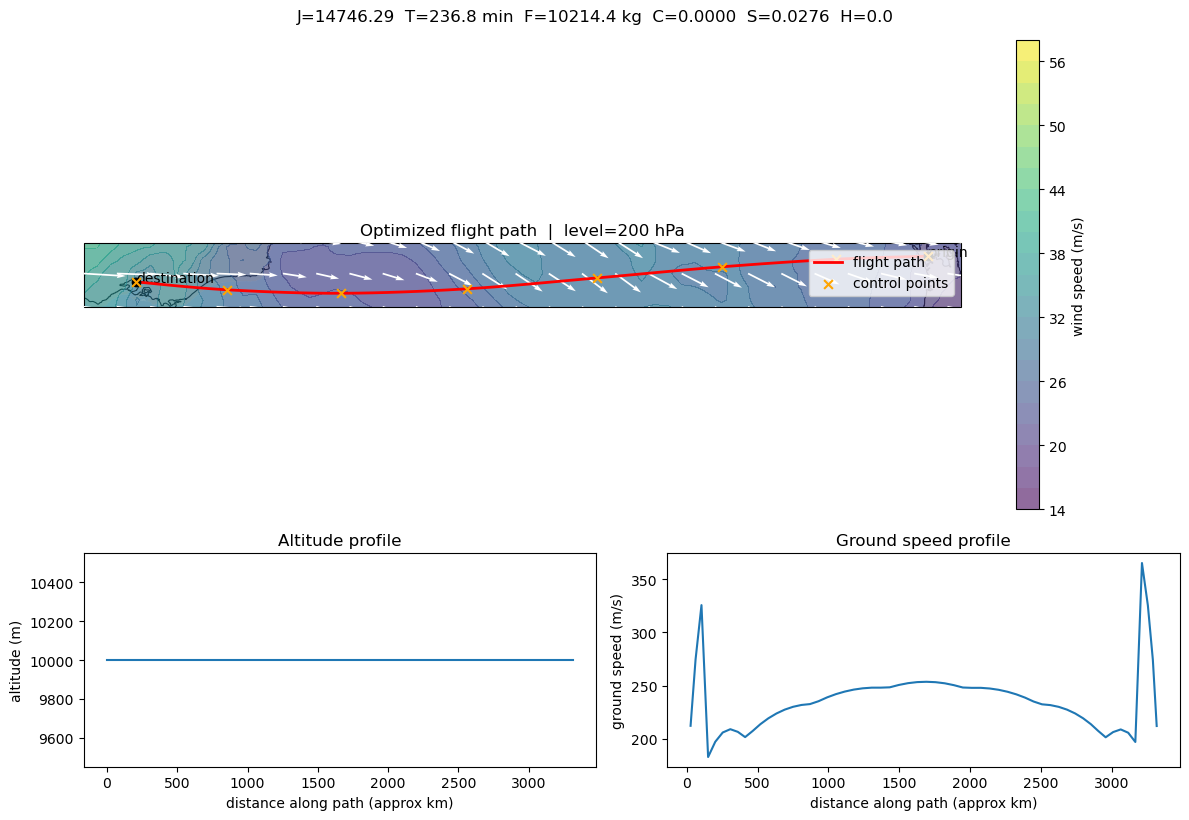

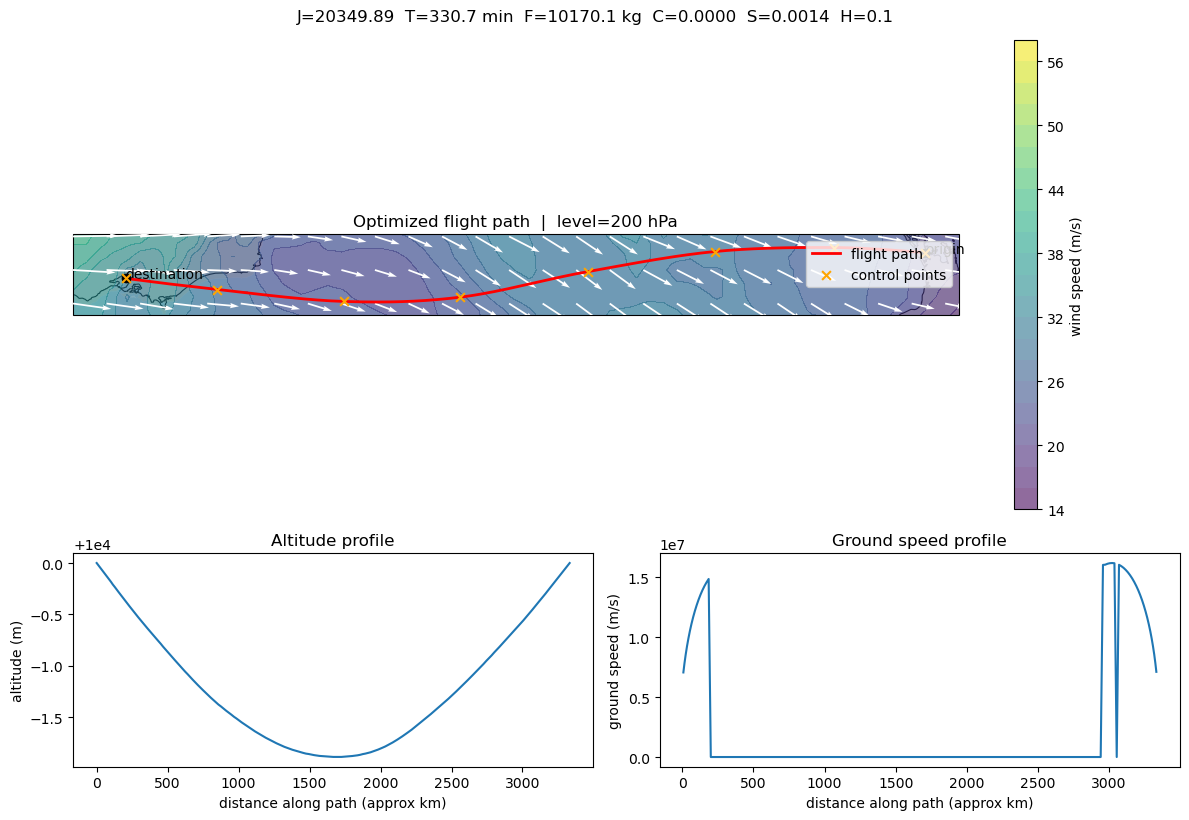

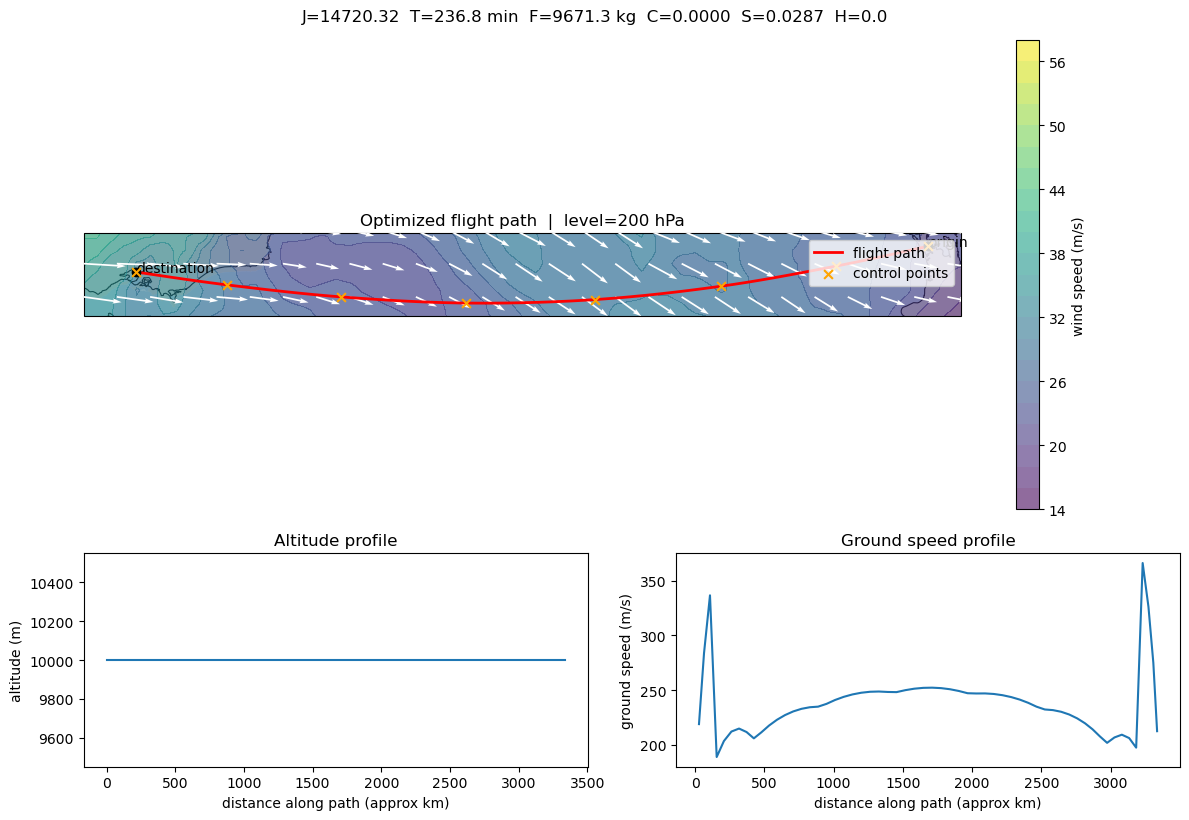

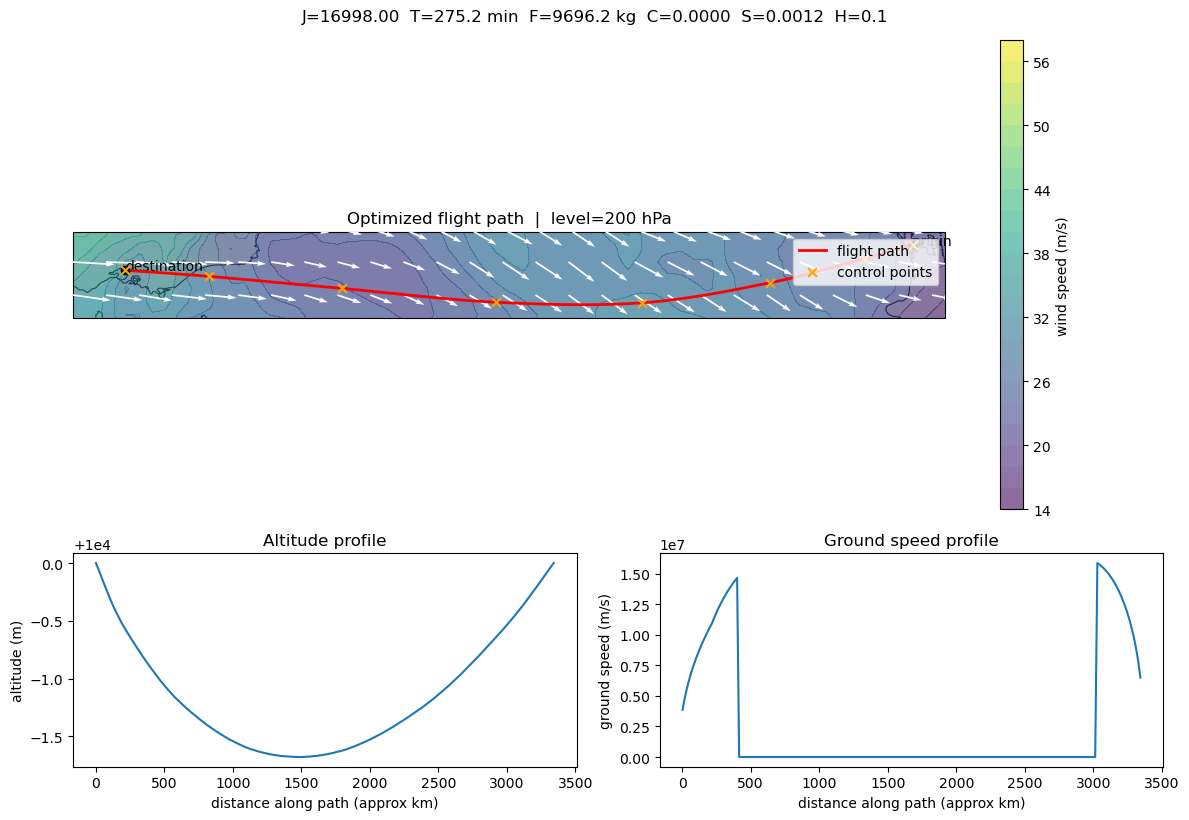

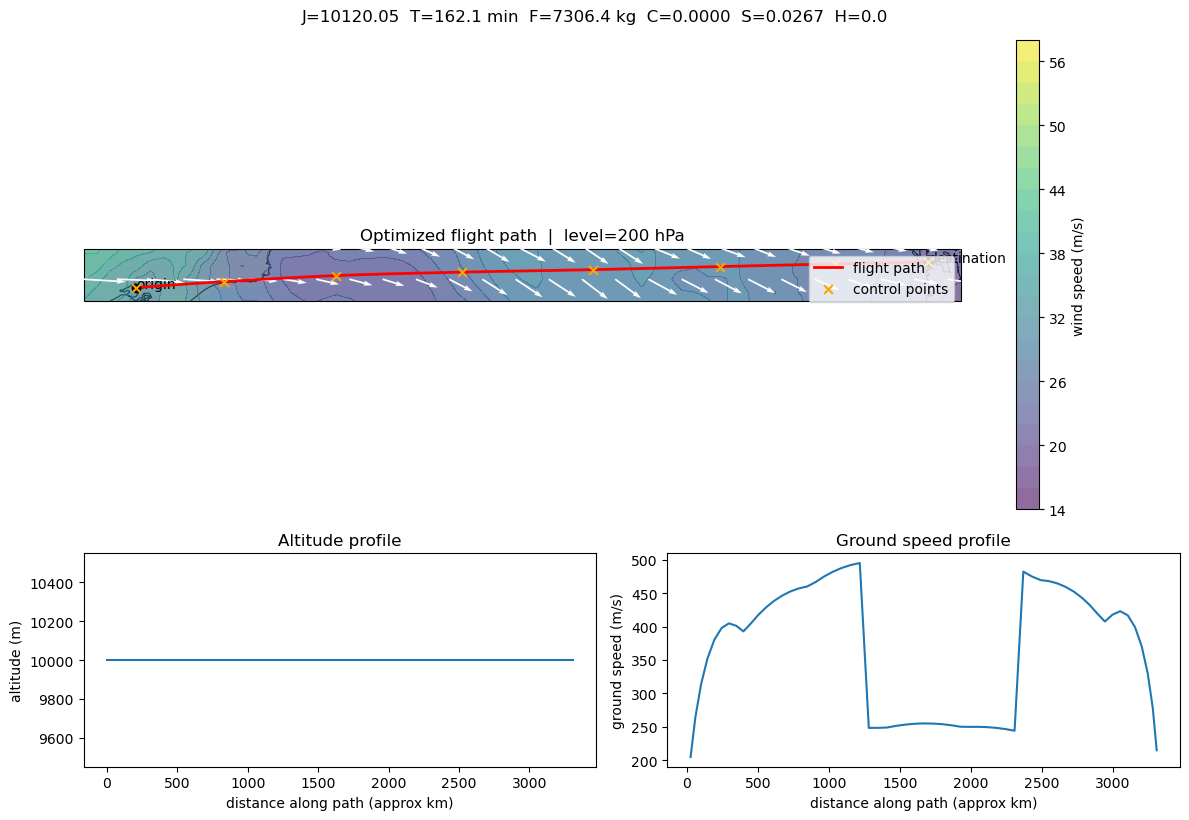

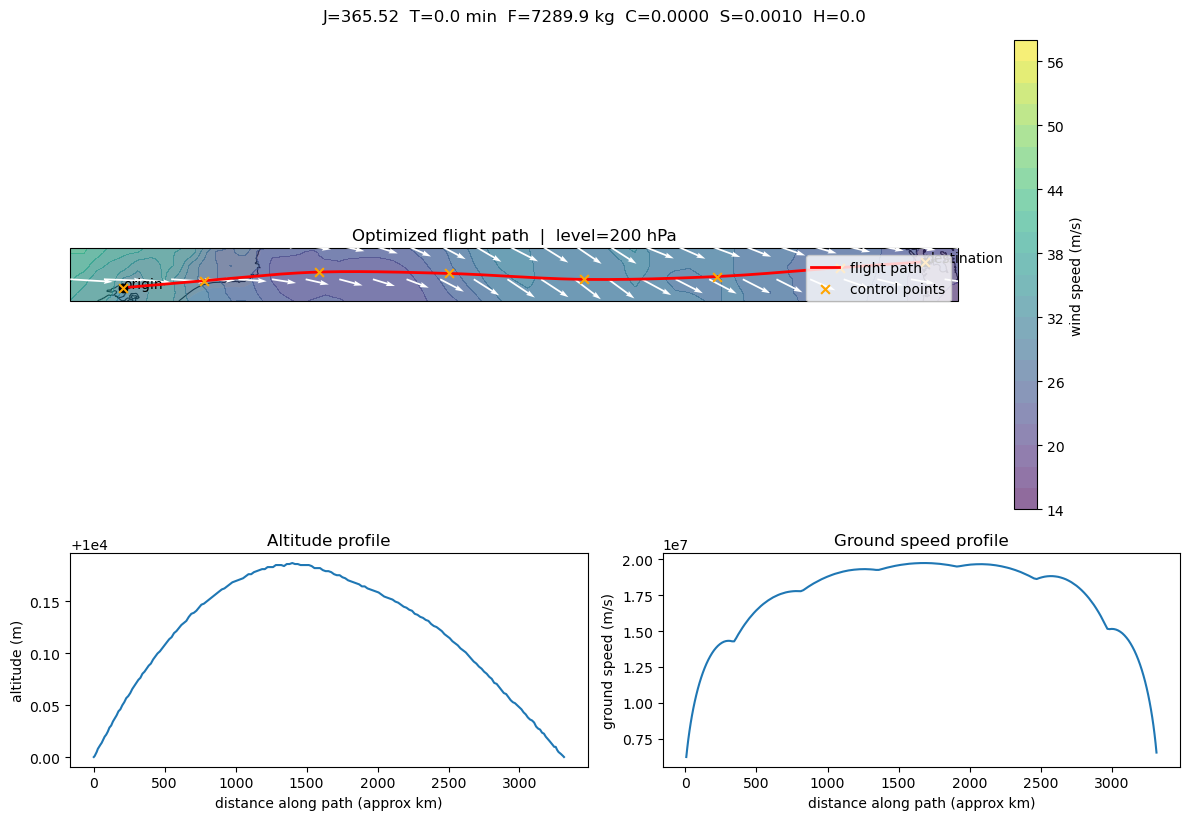

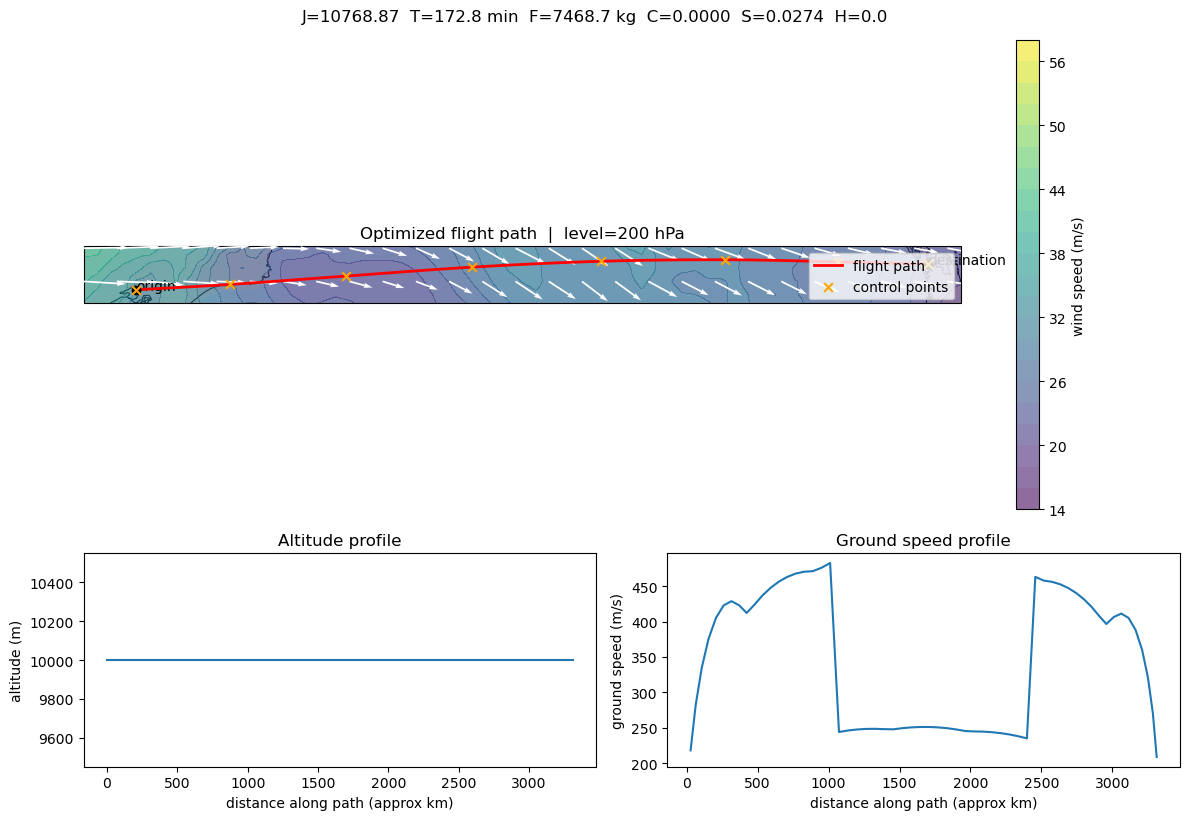

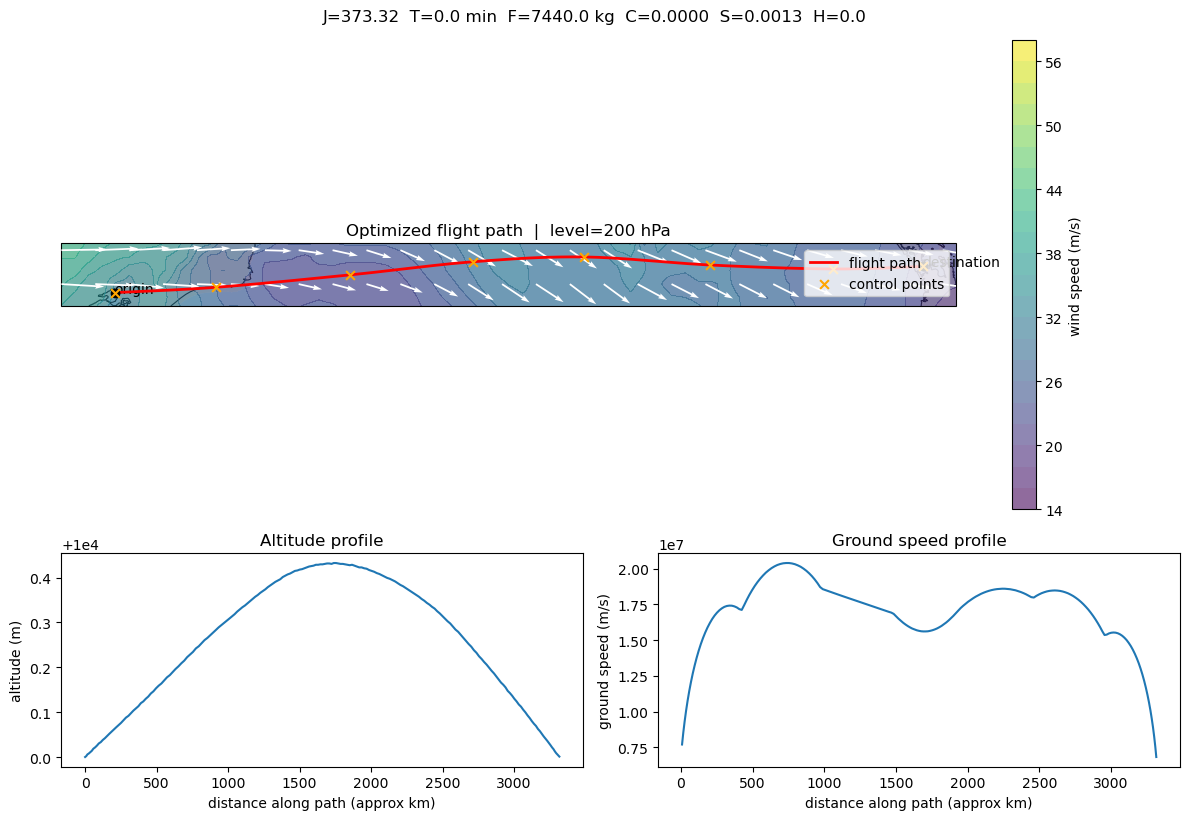

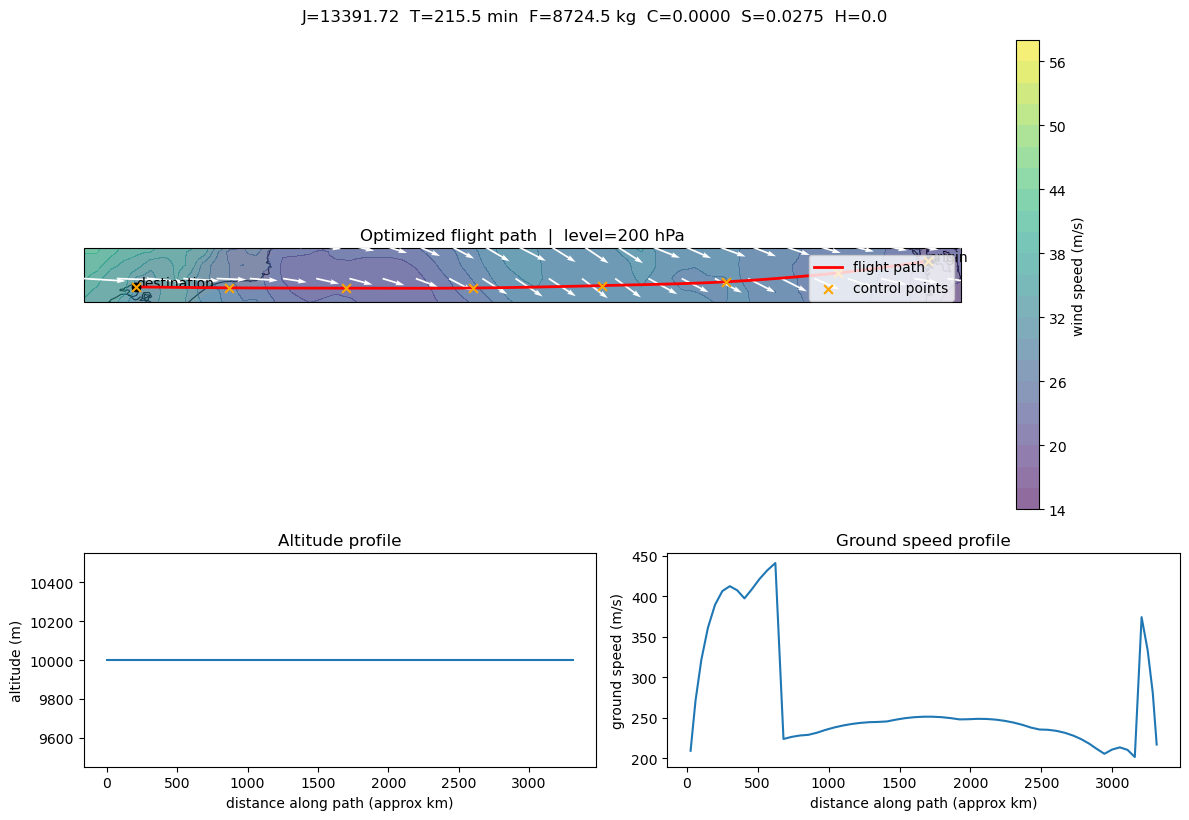

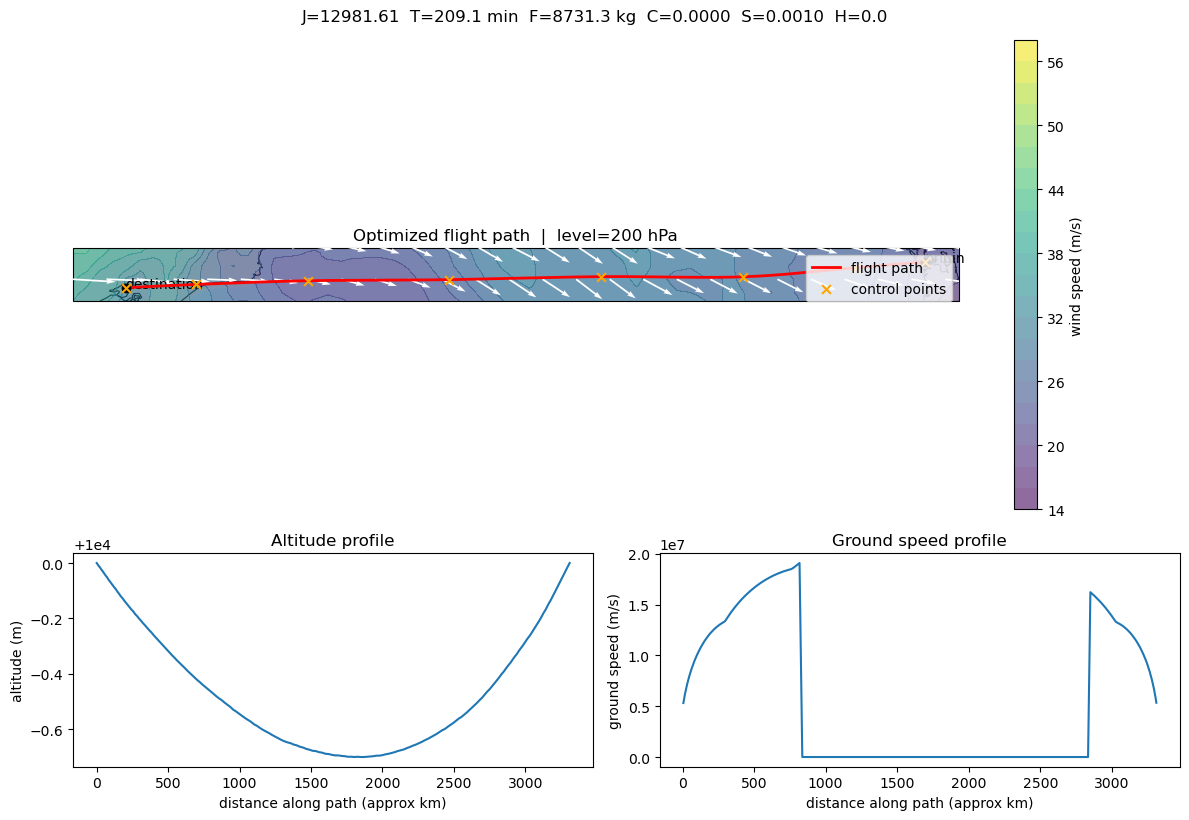

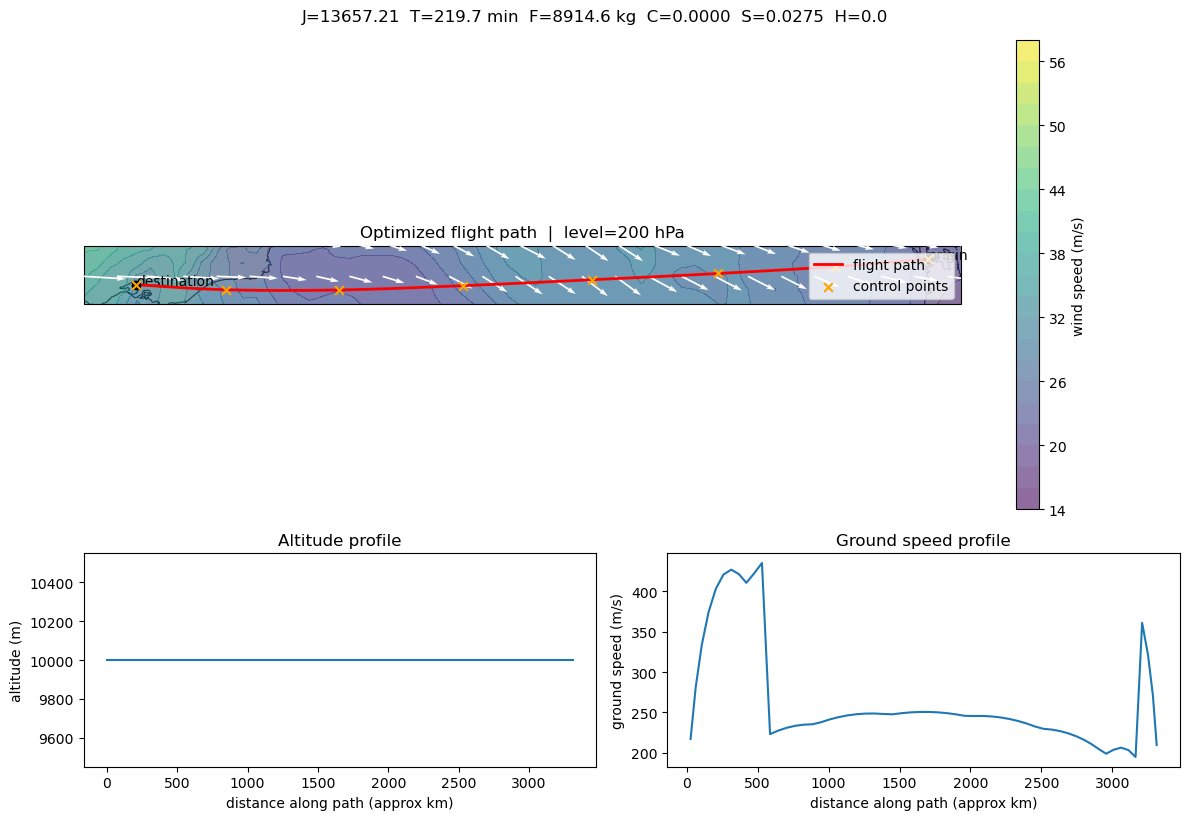

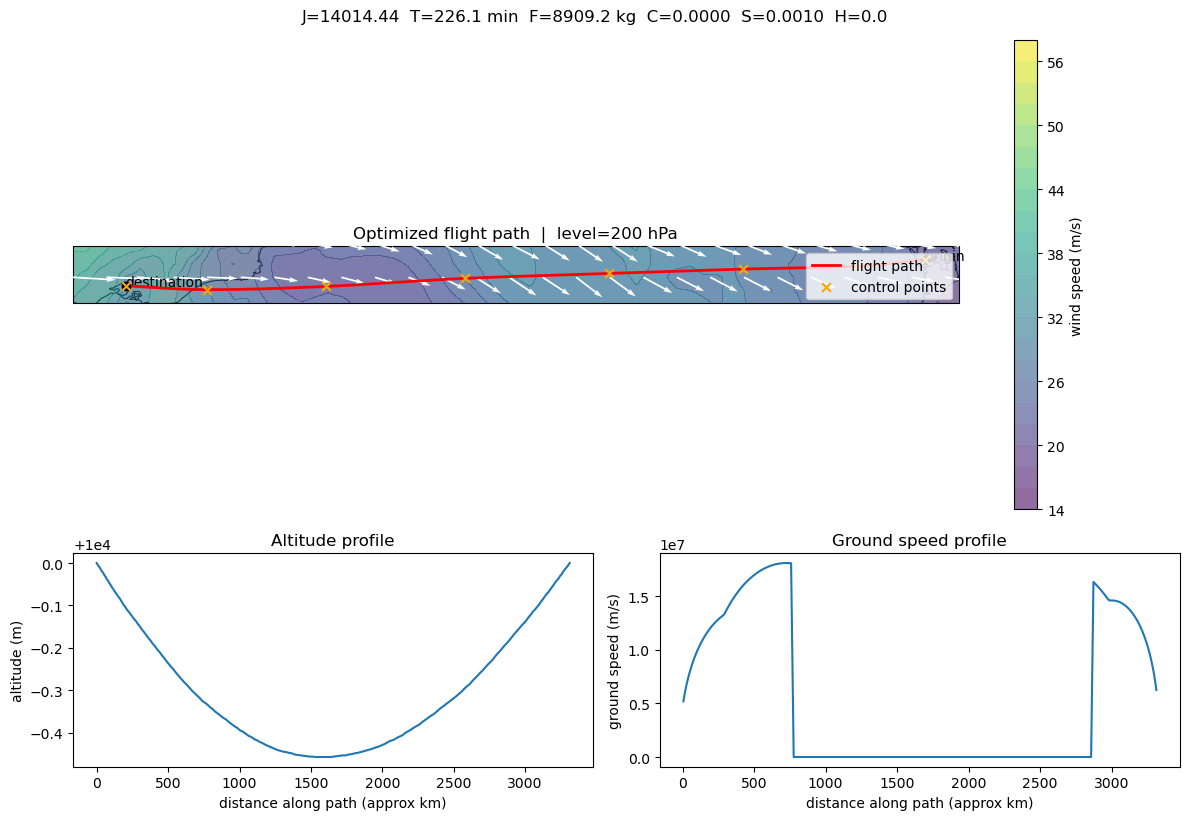

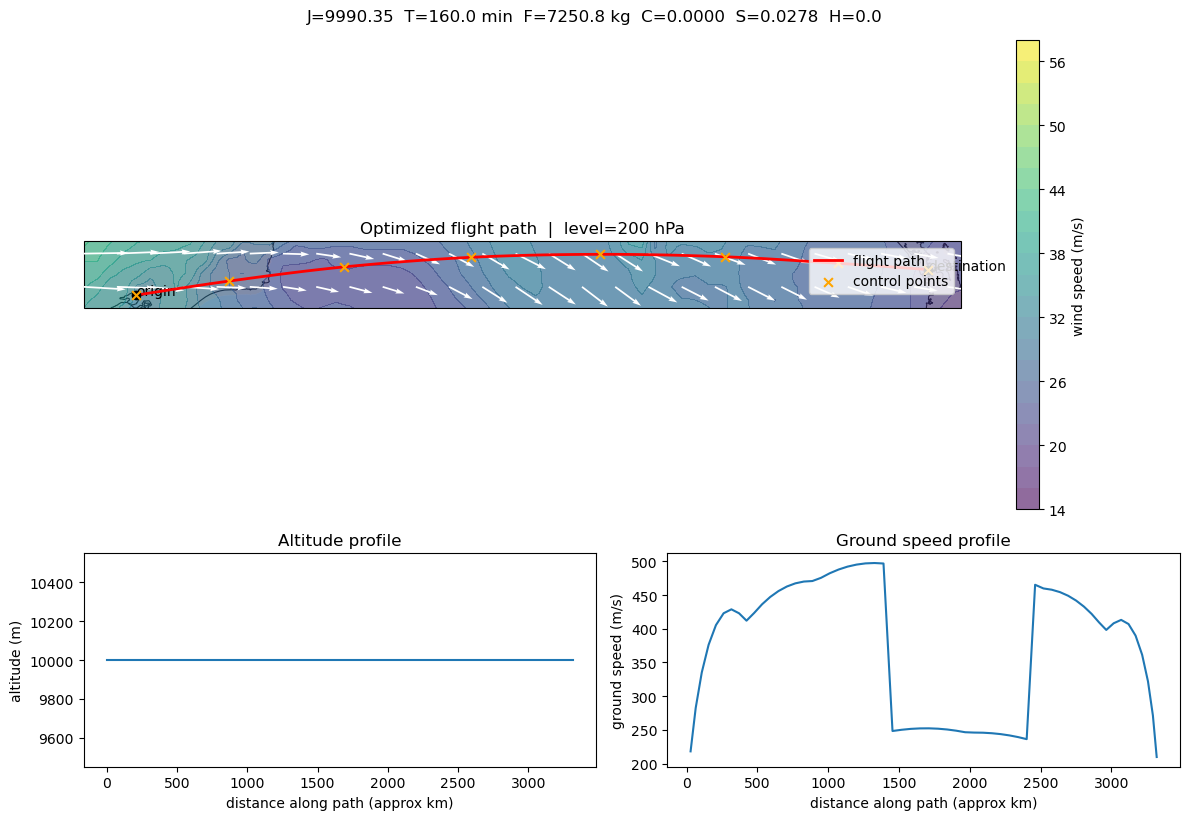

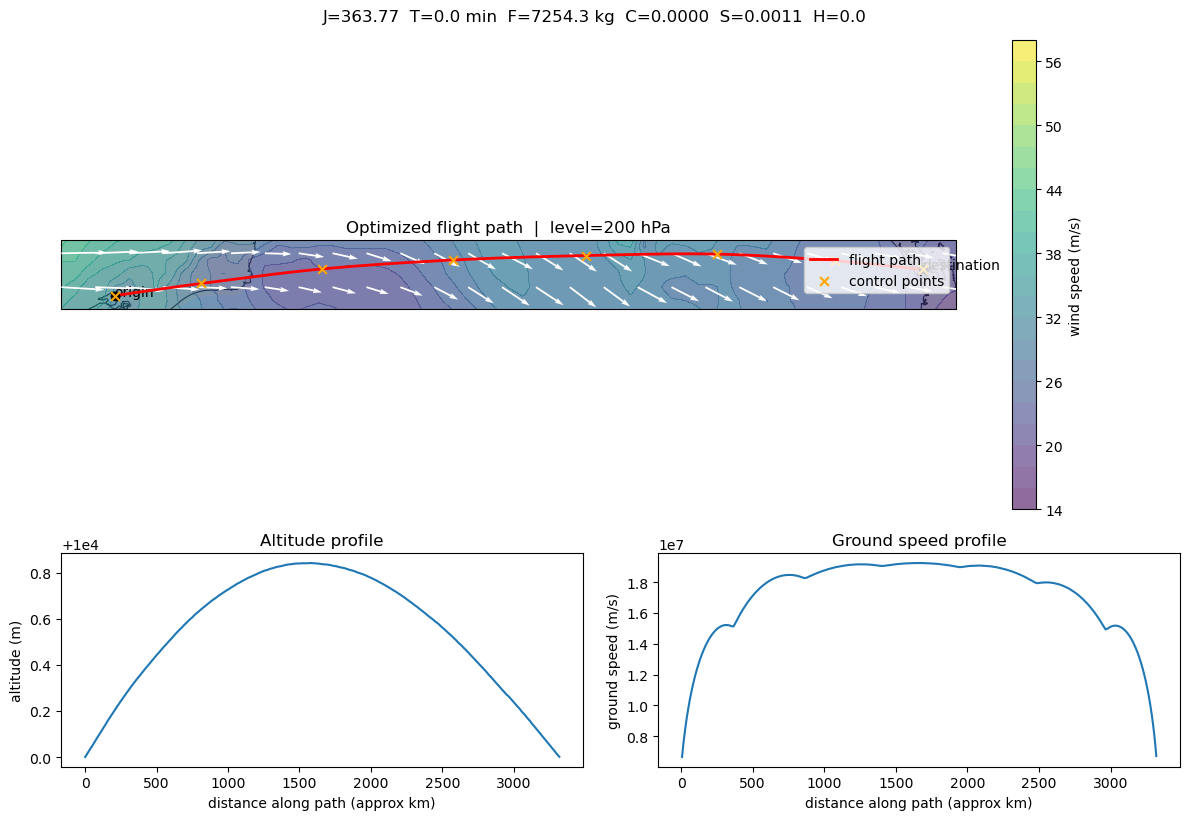

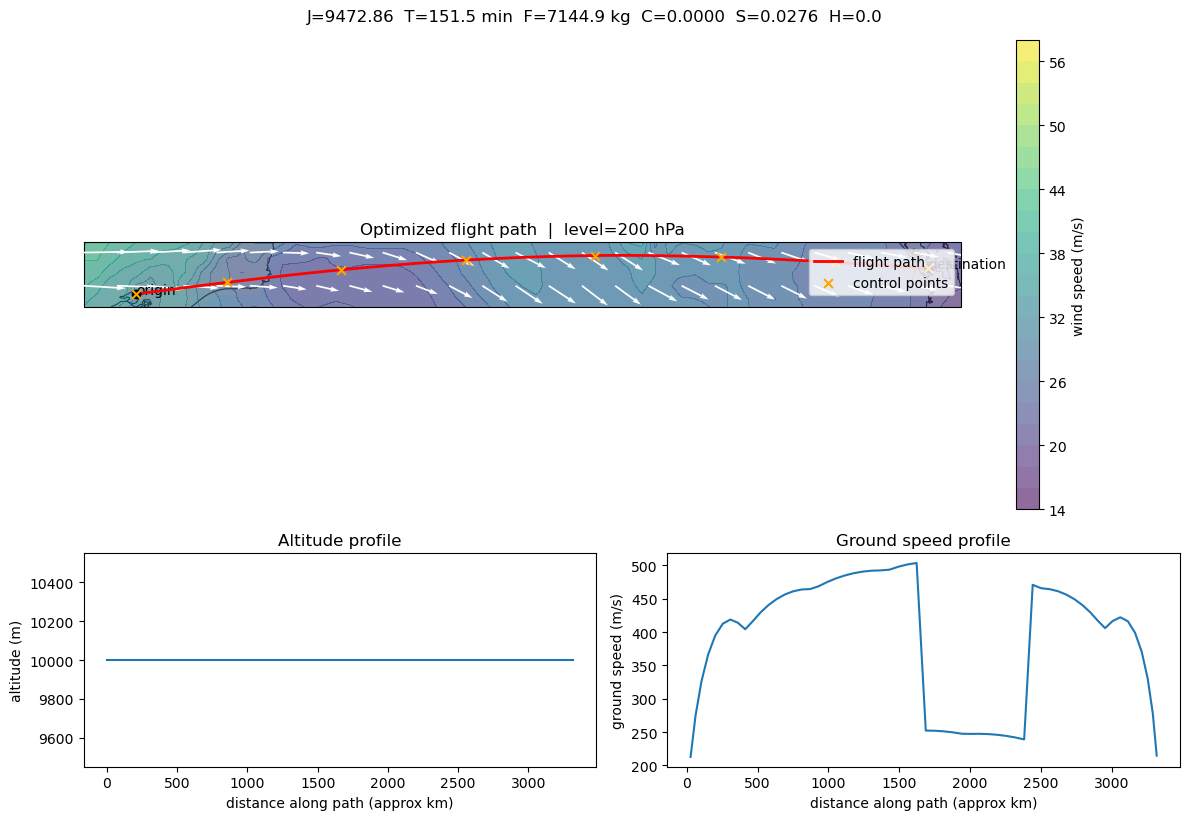

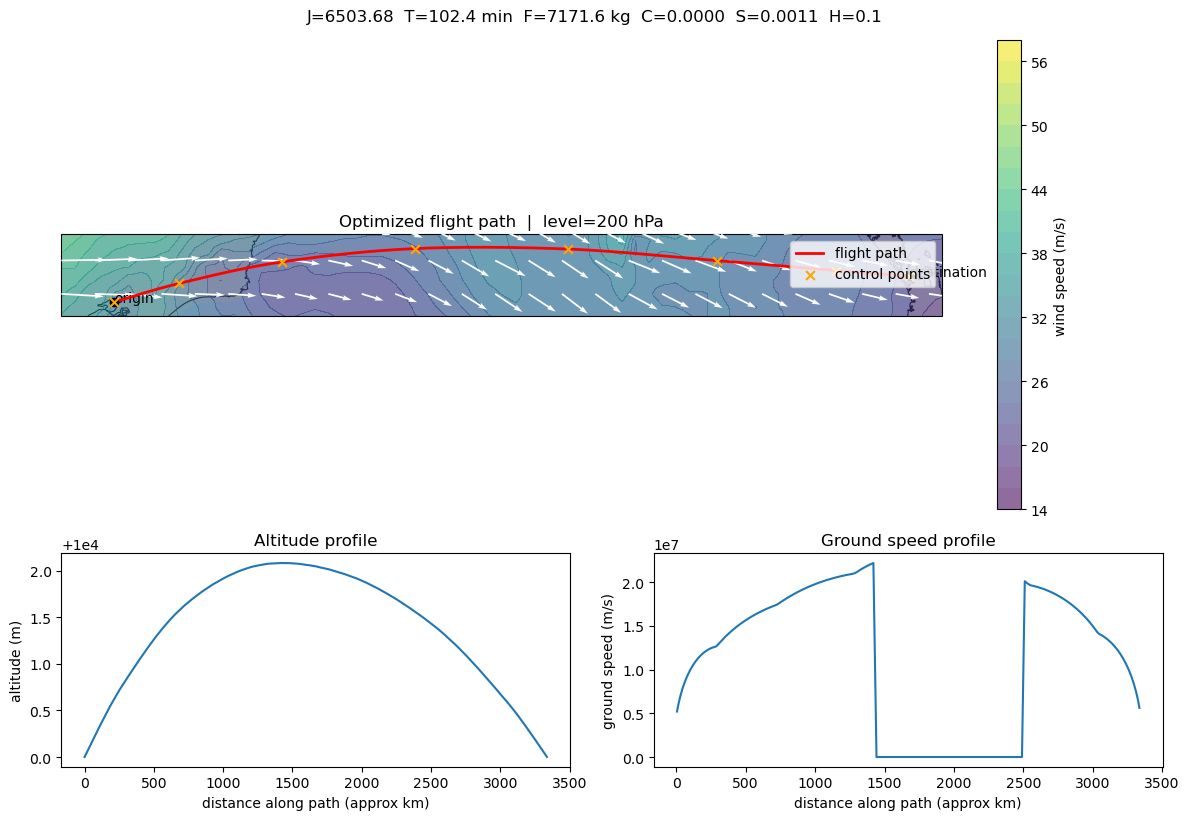

In [46]:
for flight in flights:
    windfield = WindField(ecmwf_ds, device=device)

    aircraft = PROFILES["narrowbody_jet"]

    # Origin/destination roughly spanning the domain (e.g. Sydney-ish -> Christchurch-ish)
    origin = flight["from"]
    destination = flight["to"]
    n_control_points = 8
    lats = np.linspace(origin[0], destination[0], n_control_points)
    lons = np.linspace(origin[1], destination[1], n_control_points)
    alts = np.full(n_control_points, 10000.0)
    waypoints = np.stack([lats, lons, alts], axis=1)

    trajectory = Trajectory(waypoints, start_time=np.datetime64(flight["time"]), fixed_endpoints=True, device=device)

    weights = LossWeights(time=1.0, fuel=0.05, curvature=5e4, smoothness=1e3, altitude=0.02)

    optimizer = TrajectoryOptimizer(trajectory, windfield, aircraft, weights=weights, num_samples=20, lr=0.05)
    optimizer.run(num_iters=120, verbose=False, log_every=20)

    fig = plot_trajectory(trajectory, windfield, aircraft, weights=weights, num_samples=60)

    # save in ./data/trajectories/trajectory_{flight['from']}_{flight['to']}_{flight['time']}.png
    output_dir = "./data/trajectories"
    os.makedirs(output_dir, exist_ok=True)
    output_file = os.path.join(output_dir, f"trajectory_{flight['from']}_{flight['to']}_{flight['time']}_ifs.png")
    fig.savefig(output_file, dpi=300, bbox_inches='tight')

    windfield2 = WindField(era5_ds, device=device)
    result_on_era5 = optimizer.evaluate(windfield=windfield2)

    optimizer2 = TrajectoryOptimizer(trajectory, windfield2, aircraft, weights=weights, num_samples=120, lr=0.05)
    optimizer2.run(num_iters=120, verbose=False, log_every=20)
    result_era5_optimized = optimizer2.evaluate(windfield=windfield2)
    fig = plot_trajectory(trajectory, windfield, aircraft, weights=weights, num_samples=200)
    output_file = os.path.join(output_dir, f"trajectory_{flight['from']}_{flight['to']}_{flight['time']}_era5.png")
    fig.savefig(output_file, dpi=300, bbox_inches='tight')

    fuel_savings = result_on_era5.as_dict()['fuel_kg'] - result_era5_optimized.as_dict()['fuel_kg']

    # save the fuel savings to a csv file in ./data/table/fuel_savings.csv
    # create or append to the file
    output_table_dir = "./data/table"
    os.makedirs(output_table_dir, exist_ok=True)
    output_table_file = os.path.join(output_table_dir, "fuel_savings.csv")
    if not os.path.exists(output_table_file):
        with open(output_table_file, 'w') as f:
            f.write("from,to,time,fuel_savings_kg\n")
    with open(output_table_file, 'a') as f:
        f.write(f"{flight['from']},{flight['to']},{flight['time']},{fuel_savings:.2f}\n")

    print(f"Processed flight from {flight['from']} to {flight['to']} at {flight['time']}. Fuel savings: {fuel_savings:.2f} kg")
    print(f"Fuel savings for the day (estimate, NZD) = {fuel_savings * 4 * 1.90:.2f} NZD")

In [47]:
# print the total fuel savings across all flights
import pandas as pd
fuel_savings_df = pd.read_csv(output_table_file)
total_fuel_savings = fuel_savings_df['fuel_savings_kg'].sum()

# multiply by 4 to account for skipped flights (only 1/4 of flights were processed)
total_fuel_savings *= 4

# print the total fuel savings
print(f"Total fuel savings across all flights: {total_fuel_savings:.2f} kg")

# $1.90 NZD per kg of jet fuel, so multiply by 1.90 to get the total fuel savings in NZD
total_fuel_savings_nzd = total_fuel_savings * 1.90
print(f"Total fuel savings across all flights: {total_fuel_savings_nzd:.2f} NZD")

Total fuel savings across all flights: 1841.88 kg
Total fuel savings across all flights: 3499.57 NZD


Text(0, 0.5, 'Number of Flights')

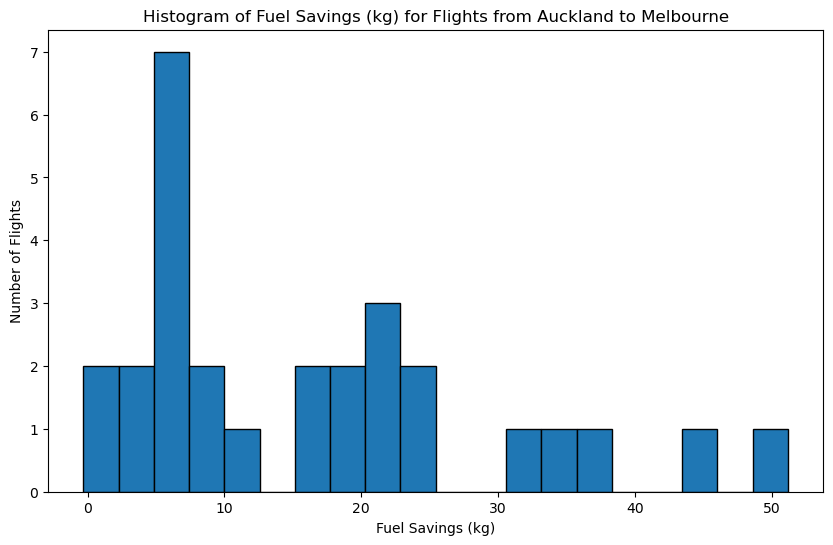

In [48]:
# plot a histogram of the fuel savings
plt.figure(figsize=(10, 6))
plt.hist(fuel_savings_df['fuel_savings_kg'], bins=20, edgecolor='black')
plt.title('Histogram of Fuel Savings (kg) for Flights from Auckland to Melbourne')
plt.xlabel('Fuel Savings (kg)')
plt.ylabel('Number of Flights')

Text(0, 0.5, 'Average Fuel Savings (kg)')

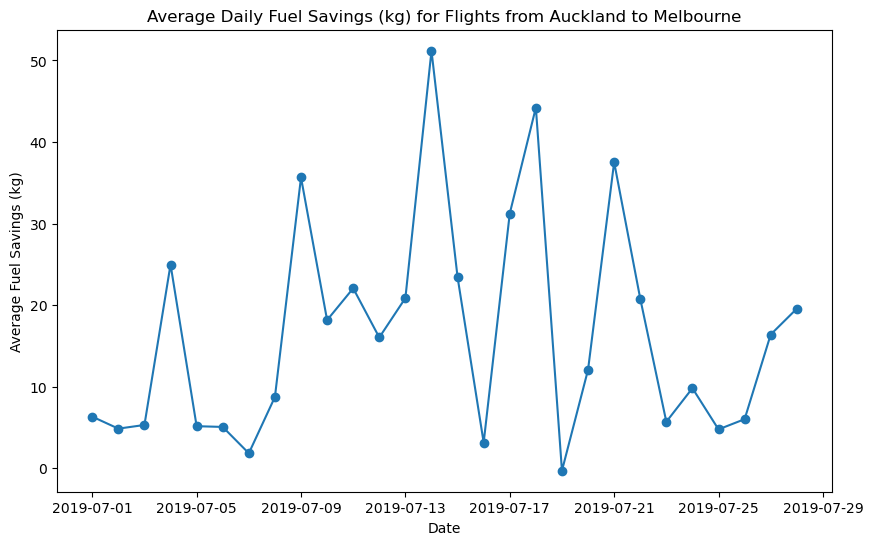

In [57]:
# trend average fuel savings over time. time is the index
daily_fuel_savings = fuel_savings_df.resample('D')

daily_fuel_savings = fuel_savings_df.groupby(pd.to_datetime(fuel_savings_df.index).date)['fuel_savings_kg'].mean()

# create the plot
plt.figure(figsize=(10, 6))
plt.plot(daily_fuel_savings.index, daily_fuel_savings.values, marker='o')
plt.title('Average Daily Fuel Savings (kg) for Flights from Auckland to Melbourne')
plt.xlabel('Date')
plt.ylabel('Average Fuel Savings (kg)')